In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
from plotly import graph_objects as go
from plotly import express as px

In [20]:
import os

In [21]:
print("Current directory:", os.getcwd())

Current directory: c:\Users\MEGH BAVARVA\Desktop\Data Scientist\Project\Real_Estate\Code\notebooks


In [22]:
from pathlib import Path

file_path = Path.cwd().parent / 'data' / 'gandhinagar_property_apartments_final.csv'
df = pd.read_csv(file_path)
df.head()

,Price,Area,Bathrooms,Balconies,Current_Floor,Total_Floors,Furnishing_Status,Mapped_Area,Facing,Property_Age,Bedrooms,Area_Type,Property_Status
0,126.00,2916.0,3.0,1.0,4.0,8.0,Unknown,Sargasan,Unknown,New,3.0,Super Built-up,Ready_to_Move
1,51.99,1755.0,3.0,2.0,3.0,7.0,Unknown,Pethapur,Unknown,New,3.0,Super Built-up,Under_Construction
2,97.00,1908.0,3.0,2.0,4.0,8.0,Unknown,Raysan,Unknown,New,3.0,Super Built-up,Ready_to_Move
3,125.00,2205.0,2.0,2.0,9.0,13.0,Unknown,Raysan,Unknown,New,3.0,Carpet,Ready_to_Move
4,79.00,1755.0,3.0,1.0,8.0,13.0,unfurnished,Randesan,Unknown,5-10 years,3.0,Carpet,Ready_to_Move


In [23]:
data = {
    'Mapped_Area': [
        'Sargasan', 'Kudasan', 'Gift City', 'Randesan', 'Vavol', 'Raysan', 'Koba', 'Kalol',
        'Pethapur', 'Randheja', 'Khoraj', 'Uvarsad', 'Chiloda', 'SP Ring Road', 'Sector 22',
        'Adalaj', 'Gandhinagar Taluka', 'Kolavada', 'Sector 26', 'Karai', 'SG Highway',
        'Dahegam', 'Sughad', 'Valad', 'Ambapur', 'Sector 19', 'Sector 28', 'Sector 24',
        'Sector 21', 'Sector 8', 'Sector 6', 'Sector 11', 'Other'
    ],
    'Latitude': [
        23.185, 23.183, 23.166, 23.173, 23.225, 23.187, 23.145, 23.246,
        23.270, 23.298, 23.137, 23.220, 23.250, 23.120, 23.240,
        23.165, 23.216, 23.205, 23.250, 23.160, 23.080,
        23.170, 23.140, 23.290, 23.177, 23.230, 23.260, 23.245,
        23.235, 23.215, 23.205, 23.220, 23.216
    ],
    'Longitude': [
        72.616, 72.631, 72.681, 72.646, 72.623, 72.661, 72.665, 72.497,
        72.676, 72.625, 72.579, 72.596, 72.730, 72.590, 72.670,
        72.582, 72.683, 72.590, 72.690, 72.710, 72.520,
        72.820, 72.610, 72.640, 72.592, 72.660, 72.700, 72.675,
        72.665, 72.650, 72.645, 72.655, 72.683
    ]
}

df_coords = pd.DataFrame(data)
print(df_coords.head())

  Mapped_Area  Latitude  Longitude
0    Sargasan    23.185     72.616
1     Kudasan    23.183     72.631
2   Gift City    23.166     72.681
3    Randesan    23.173     72.646
4       Vavol    23.225     72.623


In [24]:
new_df=df.merge(df_coords, on='Mapped_Area')
new_df.head()

,Price,Area,Bathrooms,Balconies,Current_Floor,Total_Floors,Furnishing_Status,Mapped_Area,Facing,Property_Age,Bedrooms,Area_Type,Property_Status,Latitude,Longitude
0,126.00,2916.0,3.0,1.0,4.0,8.0,Unknown,Sargasan,Unknown,New,3.0,Super Built-up,Ready_to_Move,23.185,72.616
1,51.99,1755.0,3.0,2.0,3.0,7.0,Unknown,Pethapur,Unknown,New,3.0,Super Built-up,Under_Construction,23.270,72.676
2,97.00,1908.0,3.0,2.0,4.0,8.0,Unknown,Raysan,Unknown,New,3.0,Super Built-up,Ready_to_Move,23.187,72.661
3,125.00,2205.0,2.0,2.0,9.0,13.0,Unknown,Raysan,Unknown,New,3.0,Carpet,Ready_to_Move,23.187,72.661
4,79.00,1755.0,3.0,1.0,8.0,13.0,unfurnished,Randesan,Unknown,5-10 years,3.0,Carpet,Ready_to_Move,23.173,72.646


In [25]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              1300 non-null   float64
 1   Area               1300 non-null   float64
 2   Bathrooms          1300 non-null   float64
 3   Balconies          1300 non-null   float64
 4   Current_Floor      1300 non-null   float64
 5   Total_Floors       1300 non-null   float64
 6   Furnishing_Status  1300 non-null   str    
 7   Mapped_Area        1300 non-null   str    
 8   Facing             1300 non-null   str    
 9   Property_Age       1300 non-null   str    
 10  Bedrooms           1300 non-null   float64
 11  Area_Type          1300 non-null   str    
 12  Property_Status    1300 non-null   str    
 13  Latitude           1300 non-null   float64
 14  Longitude          1300 non-null   float64
dtypes: float64(9), str(6)
memory usage: 152.5 KB


In [26]:
# For coordinates, take the first occurrence instead of mean
group_df = new_df.groupby('Mapped_Area').agg({
    'Price': 'mean',
    'Area': 'mean',
    'Latitude': 'first',
    'Longitude': 'first'
})

In [27]:
group_df['Price_per_SqFt'] = (group_df['Price']*100000) / group_df['Area']
group_df

,Price,Area,Latitude,Longitude,Price_per_SqFt
Mapped_Area,,,,,
Adalaj,55.333333,1243.398733,23.165,72.582,4450.168064
Ambapur,225.000000,2067.000000,23.177,72.592,10885.341074
Chiloda,47.750000,1017.586310,23.250,72.730,4692.476652
Dahegam,36.333333,989.936667,23.170,72.820,3670.268468
Gandhinagar Taluka,72.951667,1590.593333,23.216,72.683,4586.443633
Gift City,160.037754,1444.351957,23.166,72.681,11080.246259
Kalol,27.554364,788.020438,23.246,72.497,3496.655963
Karai,53.542500,1270.851125,23.160,72.710,4213.121344
Khoraj,173.362667,3069.873433,23.137,72.579,5647.225217


In [28]:
fig = px.scatter_mapbox(
    group_df.reset_index(),
    lat='Latitude',
    lon='Longitude',
    size='Area',
    color='Price_per_SqFt',
    hover_name='Mapped_Area',
    # color_continuous_scale=px.colors.cyclical.IceFire,
    color_continuous_scale='Viridis',
    zoom=10,
    height=600,
    mapbox_style='carto-positron',
    text='Mapped_Area'
)

fig.show()

C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_27132\1676602716.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [29]:
# ------------------------------
# 1. Compute Price per SqFt (₹)
# ------------------------------
# Assume `df` is your original DataFrame with columns:
# 'Mapped_Area', 'Price' (in Lakhs), 'Area' (sq.ft.)
# And `df_coords` is the coordinates DataFrame from earlier.

new_df = df.merge(df_coords, on='Mapped_Area')
new_df['Price_inr'] = new_df['Price'] * 100000
new_df['Price_per_SqFt'] = new_df['Price_inr'] / new_df['Area']

# ------------------------------
# 2. Group by Mapped_Area
# ------------------------------
group_df = new_df.groupby('Mapped_Area').agg({
    'Price': 'mean',
    'Area': 'mean',
    'Price_per_SqFt': 'mean',
    'Latitude': 'first',
    'Longitude': 'first'
}).reset_index()

# Drop any rows with missing coordinates
group_df = group_df.dropna(subset=['Latitude', 'Longitude'])

# ------------------------------
# 3. Dark background map
#    - Marker size = Area (default scaling)
#    - Color = Price_per_SqFt (Viridis scale)
#    - No explicit text size modification
# ------------------------------
fig = px.scatter_mapbox(
    group_df,
    lat='Latitude',
    lon='Longitude',
    size='Area',                    # marker size proportional to area
    color='Price_per_SqFt',         # color by price per sqft
    hover_name='Mapped_Area',
    hover_data={
        'Price': ':.1f',
        'Area': ':.0f',
        'Price_per_SqFt': ':.0f'
    },
    color_continuous_scale='Viridis',
    zoom=11,
    height=600,
    mapbox_style='carto-darkmatter',   # dark background
    text='Mapped_Area',               # show area names (default size)
    size_max=35  
)

# Optional: Slight adjustment to marker opacity for better visibility
fig.update_traces(marker=dict(opacity=0.8),
                  textfont=dict(color='#bbbbbb', size=9))

# Center the map on Gandhinagar
fig.update_layout(
    mapbox=dict(center=dict(lat=23.20, lon=72.65)),
    margin=dict(l=0, r=0, t=0, b=0)
)

fig.show()

C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_27132\3961676779.py:32: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [21]:
# df['Mapped_Area'].value_counts().to_csv('data/location_counts.csv', index=True)

In [31]:
print("Average Price : ",df['Price'].mean())
print("Total Property : ", len(df))
print("Unique Locations : ", df['Mapped_Area'].nunique())
print("Average Price per SqFt : ", (df['Price'] * 100000 / df['Area']).mean())

Average Price :  92.61096625766871
Total Property :  1304
Unique Locations :  34
Average Price per SqFt :  5931.562635667537


In [32]:
# Compute price per sqft in Rupees
df['price_inr'] = df['Price'] * 100000   # convert Lakhs → Rupees
df['price_per_sqft'] = df['price_inr'] / df['Area']

# Group by Mapped_Area
area_avg = df.groupby('Mapped_Area')['price_per_sqft'].mean().reset_index()
area_avg = area_avg.sort_values('price_per_sqft', ascending=False).head(10)

# Create horizontal bar chart
fig = px.bar(
    area_avg,
    x='price_per_sqft',
    y='Mapped_Area',
    orientation='h',
    title='Top 10 Most Expensive Areas (Avg ₹ per sq.ft.)',
    labels={'price_per_sqft': 'Average Price per sq.ft. (₹)', 'Mapped_Area': ''},
    color='price_per_sqft',
    color_continuous_scale='Reds',
    text='price_per_sqft'
)

fig.update_traces(texttemplate='₹%{text:.0f}', textposition='outside')
fig.update_layout(height=500, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

In [33]:
# Compute price per sqft in Rupees (if not already done)
df['price_inr'] = df['Price'] * 100000   # convert Lakhs → Rupees
df['price_per_sqft'] = df['price_inr'] / df['Area']

# Group by Mapped_Area and get mean price per sqft
area_avg = df.groupby('Mapped_Area')['price_per_sqft'].mean().reset_index()
area_avg = area_avg.sort_values('price_per_sqft', ascending=True).head(10)   # ascending = cheapest first

# Create horizontal bar chart
fig = px.bar(
    area_avg,
    x='price_per_sqft',
    y='Mapped_Area',
    orientation='h',
    title='Top 10 Most Affordable Areas (Lowest ₹ per sq.ft.)',
    labels={'price_per_sqft': 'Average Price per sq.ft. (₹)', 'Mapped_Area': ''},
    color='price_per_sqft',
    color_continuous_scale='Greens_r',   # darker green = lower price
    text='price_per_sqft'
)

fig.update_traces(texttemplate='₹%{text:.0f}', textposition='outside')
fig.update_layout(height=500, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

In [ ]:
/app# Price vs Area scatter plot
scatter_df = df.dropna(subset=['Area', 'Price', 'Bedrooms']).copy()
scatter_df['Bedrooms'] = scatter_df['Bedrooms'].astype(int).astype(str)

fig = px.scatter(
    scatter_df,
    x='Area',
    y='Price',
    color='Bedrooms',
    title='Price vs Area by Bedroom Count',
    labels={
        'Area': 'Area (sq ft)',
        'Price': 'Price (₹ Lakhs)',
        'Bedrooms': 'Bedrooms',
    },
    height=600,
    hover_data={'Area':':.0f', 'Price':':.1f', 'Bedrooms':True},
)
fig.update_traces(
    marker=dict(size=10, opacity=0.8, line=dict(width=0.5, color='rgba(0,0,0,0.12)'))
)
fig.update_layout(
    template='plotly_white',
    legend_title_text='Bedrooms',
    xaxis=dict(gridcolor='#e5e7eb'),
    yaxis=dict(gridcolor='#e5e7eb'),
    margin=dict(l=40, r=20, t=60, b=40),
)
fig.show()

# Average price by BHK type
bhk_df = df.dropna(subset=['Bedrooms', 'Price']).copy()
bhk_df['Bedrooms'] = bhk_df['Bedrooms'].astype(int)
bhk_df['BHK'] = bhk_df['Bedrooms'].apply(lambda x: f'{x} BHK' if x < 4 else '4+ BHK')

avg_bhk = bhk_df.groupby('BHK', as_index=False)['Price'].mean()
order = ['1 BHK', '2 BHK', '3 BHK', '4+ BHK']
avg_bhk['BHK'] = pd.Categorical(avg_bhk['BHK'], categories=order, ordered=True)
avg_bhk = avg_bhk.sort_values('BHK')

fig = px.bar(
    avg_bhk,
    x='BHK',
    y='Price',
    text='Price',
    color='Price',
    color_continuous_scale='Blues',
    title='Average Property Price by BHK Type',
    labels={'Price': 'Price (₹ Lakhs)', 'BHK': 'BHK Type'},
    height=520,
)
fig.update_traces(texttemplate='₹%{text:.1f}L', textposition='outside', marker_line_color='rgba(0,0,0,0.08)', marker_line_width=1)
fig.update_layout(
    template='plotly_white',
    yaxis=dict(gridcolor='#e5e7eb'),
    xaxis=dict(gridcolor='#e5e7eb'),
    margin=dict(l=40, r=20, t=60, b=40),
    coloraxis_showscale=False,
)
fig.show()

In [34]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- Prepare aggregated data ----------
# Assuming df has columns: 'Price' (in Lakhs), 'Area' (sqft), 'Mapped_Area'
df['price_inr'] = df['Price'] * 100000   # convert to Rupees
df['price_per_sqft'] = df['price_inr'] / df['Area']

area_summary = df.groupby('Mapped_Area').agg(
    avg_price_lakhs=('Price', 'mean'),
    avg_price_per_sqft=('price_per_sqft', 'mean'),
    avg_area=('Area', 'mean'),
    count=('Price', 'count')
).round(2).reset_index()

# Sort areas alphabetically for dropdown
area_list = sorted(area_summary['Mapped_Area'].tolist())

# ---------- Widgets ----------
area1 = widgets.Dropdown(
    options=area_list,
    value=area_list[0],
    description='Area 1:',
    style={'description_width': 'initial'}
)
area2 = widgets.Dropdown(
    options=area_list,
    value=area_list[1] if len(area_list) > 1 else area_list[0],
    description='Area 2:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

# ---------- Comparison function ----------
def compare_areas(a1, a2):
    with output:
        clear_output(wait=True)
        if a1 == a2:
            print("⚠️ Please select two different areas.")
            return
        
        # Get data for each area
        row1 = area_summary[area_summary['Mapped_Area'] == a1].iloc[0]
        row2 = area_summary[area_summary['Mapped_Area'] == a2].iloc[0]
        
        # Build comparison DataFrame
        comparison = pd.DataFrame({
            'Metric': ['Avg Price', 'Avg Price per SqFt', 'Avg Area (sq.ft.)', 'Number of Properties'],
            a1: [
                f"₹{row1['avg_price_lakhs']:.1f} L",
                f"₹{row1['avg_price_per_sqft']:,.0f}",
                f"{row1['avg_area']:.0f}",
                f"{row1['count']}"
            ],
            a2: [
                f"₹{row2['avg_price_lakhs']:.1f} L",
                f"₹{row2['avg_price_per_sqft']:,.0f}",
                f"{row2['avg_area']:.0f}",
                f"{row2['count']}"
            ]
        })
        
        # Style the table
        print(f"\n📊 Comparison: {a1}  vs  {a2}\n")
        display(comparison.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# ---------- Event handlers ----------
def on_change(change):
    compare_areas(area1.value, area2.value)

area1.observe(on_change, names='value')
area2.observe(on_change, names='value')

# ---------- Display UI ----------
display(widgets.HBox([area1, area2]))
display(output)

# Initial comparison
compare_areas(area1.value, area2.value)

Output()

In [35]:
# Ensure price per sqft is computed (in Rupees)
df['price_inr'] = df['Price'] * 100000
df['price_per_sqft'] = df['price_inr'] / df['Area']

# Define segmentation thresholds (adjust based on your market)
def segment(pps):
    if pps < 4000:
        return 'Affordable'
    elif pps < 7000:
        return 'Premium'
    else:
        return 'Luxury'

df['segment'] = df['price_per_sqft'].apply(segment)

# Count properties in each segment
segment_counts = df['segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Bar chart
fig = px.bar(
    segment_counts,
    x='Segment',
    y='Count',
    color='Segment',
    color_discrete_map={'Affordable': 'green', 'Premium': 'gold', 'Luxury': 'crimson'},
    title='Property Distribution by Price Segment (₹/sq.ft.)',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Price Segment',
    yaxis_title='Number of Properties',
    showlegend=False,
    height=450
)
fig.show()

# Optional: Show percentages
total = len(df)
print("Market Segmentation:")
for seg in ['Affordable', 'Premium', 'Luxury']:
    cnt = segment_counts[segment_counts['Segment'] == seg]['Count'].values[0]
    pct = cnt/total*100
    print(f"  {seg}: {cnt} properties ({pct:.1f}%)")

Market Segmentation:
  Affordable: 285 properties (21.9%)
  Premium: 730 properties (56.0%)
  Luxury: 289 properties (22.2%)


In [36]:
# Group by Bedrooms (assuming values like 1,2,3,4,5) but we'll filter to 1-4 for clarity
bhk_avg = df.groupby('Bedrooms')['Price'].mean().reset_index()
bhk_avg = bhk_avg[bhk_avg['Bedrooms'].isin([1,2,3,4])]  # common BHK types

# Create bar chart
fig = px.bar(
    bhk_avg,
    x='Bedrooms',
    y='Price',
    title='Average Property Price by BHK Type',
    labels={'Bedrooms': 'BHK', 'Price': 'Average Price (₹ Lakhs)'},
    color='Price',
    color_continuous_scale='Blues',
    text='Price'
)
fig.update_traces(texttemplate='₹%{text:.1f} L', textposition='outside')
fig.update_layout(height=450, xaxis=dict(tickmode='linear', tickvals=[1,2,3,4]))
fig.show()


In [37]:
# Filter only known furnishing statuses
furniture_map = {'unfurnished': 'Unfurnished', 'semi‑furnished': 'Semi-Furnished', 'furnished': 'Furnished'}
df_filtered = df[df['Furnishing_Status'].isin(furniture_map.keys())].copy()
df_filtered['Furnishing_Status'] = df_filtered['Furnishing_Status'].map(furniture_map)

# Group and sort
furn_avg = df_filtered.groupby('Furnishing_Status')['Price'].mean().reset_index()
furn_order = ['Unfurnished', 'Semi-Furnished', 'Furnished']
furn_avg['Furnishing_Status'] = pd.Categorical(furn_avg['Furnishing_Status'], categories=furn_order, ordered=True)
furn_avg = furn_avg.sort_values('Furnishing_Status')

# Bar chart
fig = px.bar(
    furn_avg,
    x='Furnishing_Status',
    y='Price',
    title='Average Price by Furnishing Status (Excluding Unknown)',
    labels={'Price': 'Avg Price (₹ Lakhs)', 'Furnishing_Status': ''},
    color='Furnishing_Status',
    color_discrete_map={'Unfurnished': '#6c757d', 'Semi-Furnished': '#ffc107', 'Furnished': '#28a745'},
    text='Price'
)
fig.update_traces(texttemplate='₹%{text:.1f} L', textposition='outside')
fig.update_layout(height=450, showlegend=False)
fig.show()

# Premium calculation
base = furn_avg[furn_avg['Furnishing_Status'] == 'Unfurnished']['Price'].values[0]
for _, row in furn_avg.iterrows():
    if row['Furnishing_Status'] == 'Unfurnished':
        continue
    premium = (row['Price'] - base) / base * 100
    print(f"{row['Furnishing_Status']}: ₹{row['Price']:.1f} L → {premium:.1f}% higher than Unfurnished")

Furnished: ₹84.5 L → -3.0% higher than Unfurnished


In [38]:
df=new_df

In [39]:
# Define colors before plotting
colors = ['#2ecc71', '#f1c40f', '#e74c3c']  # Green, Yellow, Red

plt.figure(figsize=(10, 6))
sns.boxplot(x='Price_Segment', y='Price_inr', data=df,
            order=['Affordable', 'Premium', 'Luxury'],
            palette=colors, showfliers=False)
plt.title('Price Distribution Within Each Segment', fontsize=14)
plt.xlabel('Price Segment')
plt.ylabel('Price (INR)')

def crore_formatter(x, p):
    return f'₹{x/1e7:.1f}Cr' if x >= 1e7 else f'₹{x/1e5:.0f}L'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(crore_formatter))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Price_Segment` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

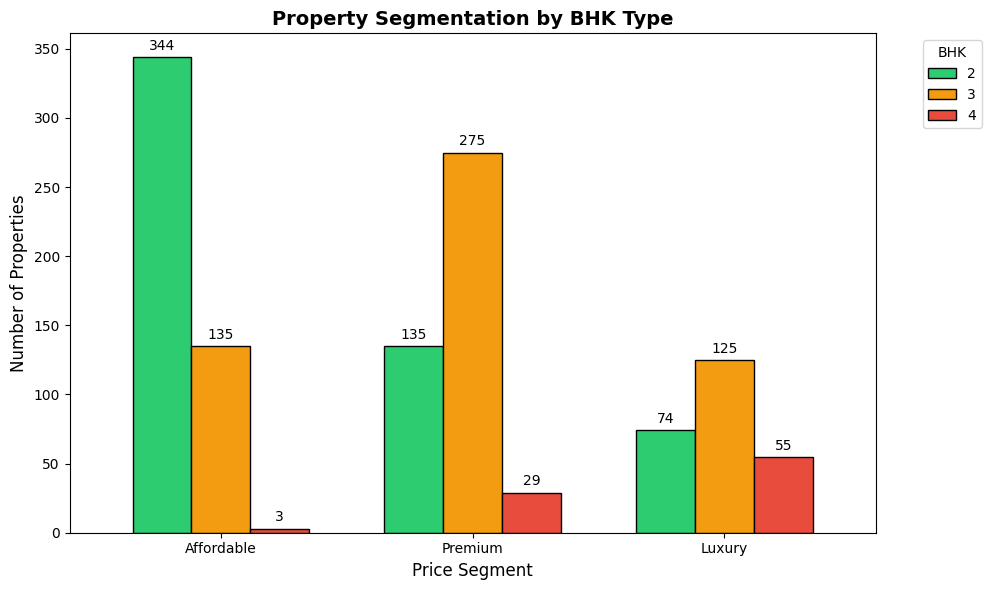


Segmentation Summary (based on your price ranges):
Segment   Affordable  Premium  Luxury
Bedrooms                             
2                344      135      74
3                135      275     125
4                  3       29      55


In [40]:
df['Bedrooms'] = df['Bedrooms'].astype(int)

# Define price ranges per BHK (in INR)
def get_segment(row):
    bhk = row['Bedrooms']
    price = row['Price_inr']
    
    # 2 BHK
    if bhk == 2:
        if price < 65e5:
            return 'Affordable'
        elif price <= 90e5:
            return 'Premium'
        else:
            return 'Luxury'
    # 3 BHK
    elif bhk == 3:
        if price < 80e5:
            return 'Affordable'
        elif price <= 120e5:
            return 'Premium'
        else:
            return 'Luxury'
    # 4 BHK
    elif bhk == 4:
        if price < 130e5:
            return 'Affordable'
        elif price <= 180e5:
            return 'Premium'
        else:
            return 'Luxury'
    else:
        return 'Other'  # ignore other bedroom counts if any

df['Segment'] = df.apply(get_segment, axis=1)

# Filter only 2,3,4 BHK
df_filtered = df[df['Bedrooms'].isin([2,3,4])]

# Create a grouped bar chart
# Pivot counts: rows = Segment, columns = Bedrooms
counts = pd.crosstab(df_filtered['Segment'], df_filtered['Bedrooms'])
# Reorder segments as Affordable, Premium, Luxury
counts = counts.reindex(['Affordable', 'Premium', 'Luxury'])
# Reorder columns as 2,3,4
counts = counts[[2,3,4]]

# Colors for each segment
colors = {'Affordable': '#2ecc71', 'Premium': '#f39c12', 'Luxury': '#e74c3c'}

# Plot
ax = counts.plot(kind='bar', figsize=(10,6), color=[colors['Affordable'], colors['Premium'], colors['Luxury']], 
                 edgecolor='black', width=0.7)
plt.title('Property Segmentation by BHK Type', fontsize=14, fontweight='bold')
plt.xlabel('Price Segment', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.legend(title='BHK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

# Optional: Print summary table
print("\nSegmentation Summary (based on your price ranges):")
summary = df_filtered.groupby(['Bedrooms', 'Segment']).size().unstack(fill_value=0)
summary = summary.reindex(['Affordable', 'Premium', 'Luxury'], axis=1)
print(summary)


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


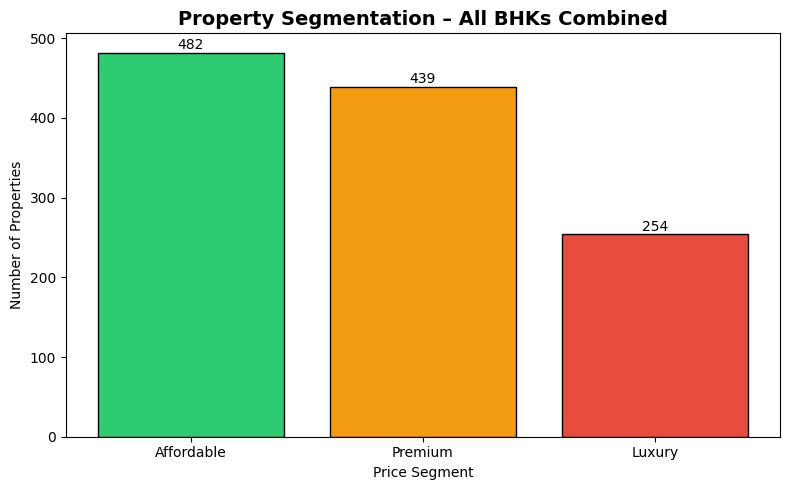


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


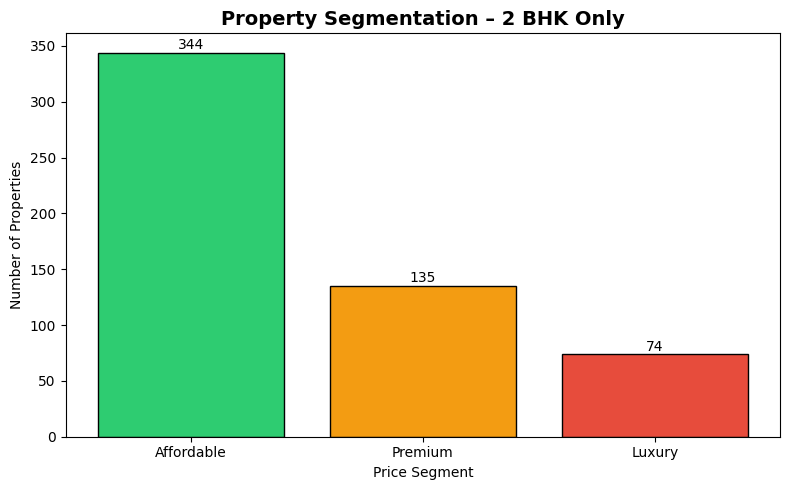


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


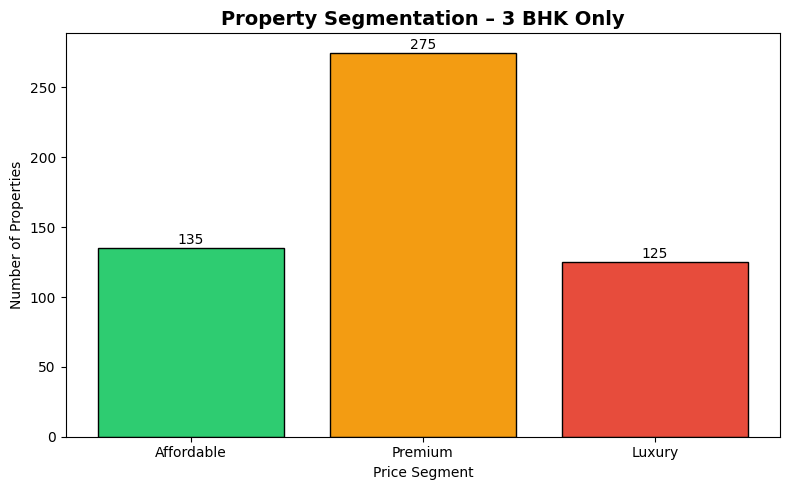


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


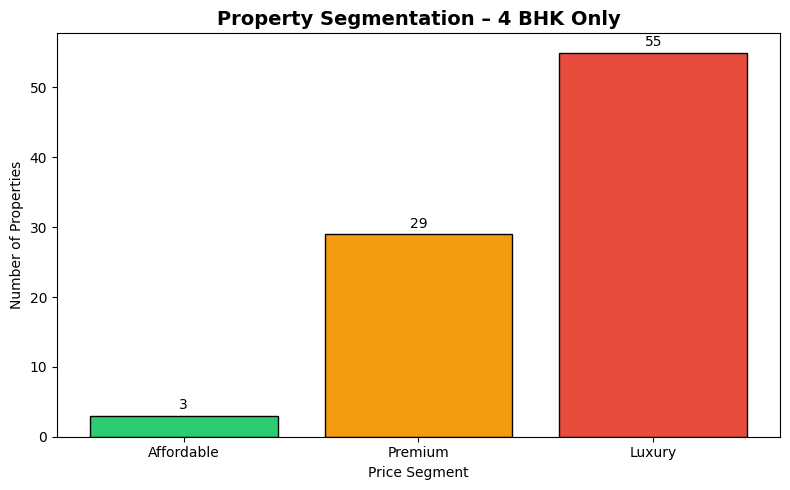


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


In [ ]:
# Assume your dataframe is `df`
df['Bedrooms'] = df['Bedrooms'].astype(int)

# --- Segmentation function (using your price brackets) ---
def get_segment(row):
    bhk = row['Bedrooms']
    price = row['Price_inr']
    if bhk == 2:
        if price < 65e5:      return 'Affordable'
        elif price <= 90e5:   return 'Premium'
        else:                 return 'Luxury'
    elif bhk == 3:
        if price < 80e5:      return 'Affordable'
        elif price <= 120e5:  return 'Premium'
        else:                 return 'Luxury'
    elif bhk == 4:
        if price < 130e5:     return 'Affordable'
        elif price <= 180e5:  return 'Premium'
        else:                 return 'Luxury'
    else:
        return None

df['Segment'] = df.apply(get_segment, axis=1)
df_filtered = df[df['Bedrooms'].isin([2,3,4])].dropna(subset=['Segment'])

segment_order = ['Affordable', 'Premium', 'Luxury']
colors = {'Affordable': '#2ecc71', 'Premium': '#f39c12', 'Luxury': '#e74c3c'}

def plot_segmentation(bhk=None):
    """bhk = None -> all BHKs together; else 2,3,4"""
    if bhk is None:
        # Aggregate all BHKs
        counts = df_filtered['Segment'].value_counts().reindex(segment_order).fillna(0)
        title = "Property Segmentation – All BHKs Combined"
    else:
        data = df_filtered[df_filtered['Bedrooms'] == bhk]
        counts = data['Segment'].value_counts().reindex(segment_order).fillna(0)
        title = f"Property Segmentation – {bhk} BHK Only"
    
    plt.figure(figsize=(8,5))
    bars = plt.bar(counts.index, counts.values, color=[colors[s] for s in counts.index], edgecolor='black')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Price Segment')
    plt.ylabel('Number of Properties')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{int(height)}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# --- Menu ---
while True:
    print("\n" + "="*40)
    print("1 - All BHKs (Affordable, Premium, Luxury mixed)")
    print("2 - Only 2 BHK")
    print("3 - Only 3 BHK")
    print("4 - Only 4 BHK")
    print("0 - Exit")
    choice = input("Enter your choice: ").strip()
    if choice == '1':
        plot_segmentation(bhk=None)
    elif choice == '2':
        plot_segmentation(bhk=2)
    elif choice == '3':
        plot_segmentation(bhk=3)
    elif choice == '4':
        plot_segmentation(bhk=4)
    elif choice == '0':
        break
    else:
        print("Invalid choice, try again.")

In [41]:
import ast
from collections import Counter
from wordcloud import WordCloud

In [42]:
import re

Total properties parsed: 1695
Length of raw_rows: 1695
First 3 rows (raw): [[], [], []]

Sample after normalization:
  raw_amenities normalized_amenities
0            []                   []
1            []                   []
2            []                   []
3            []                   []
4            []                   []
5            []                   []
6            []                   []
7            []                   []
8            []                   []
9            []                   []

Total unique amenities: 58

Top 20 amenities by count:
lift: 122
gym: 103
clubhouse: 86
parking: 79
power backup: 66
swimming pool: 60
garden: 49
security: 44
playground: 14
water supply: 12
park: 8
maintenance: 8
rainwater harvesting: 6
community hall: 6
solar: 5
electricity supply: 5
yoga: 5
home theater: 4
badminton: 4
cricket: 4


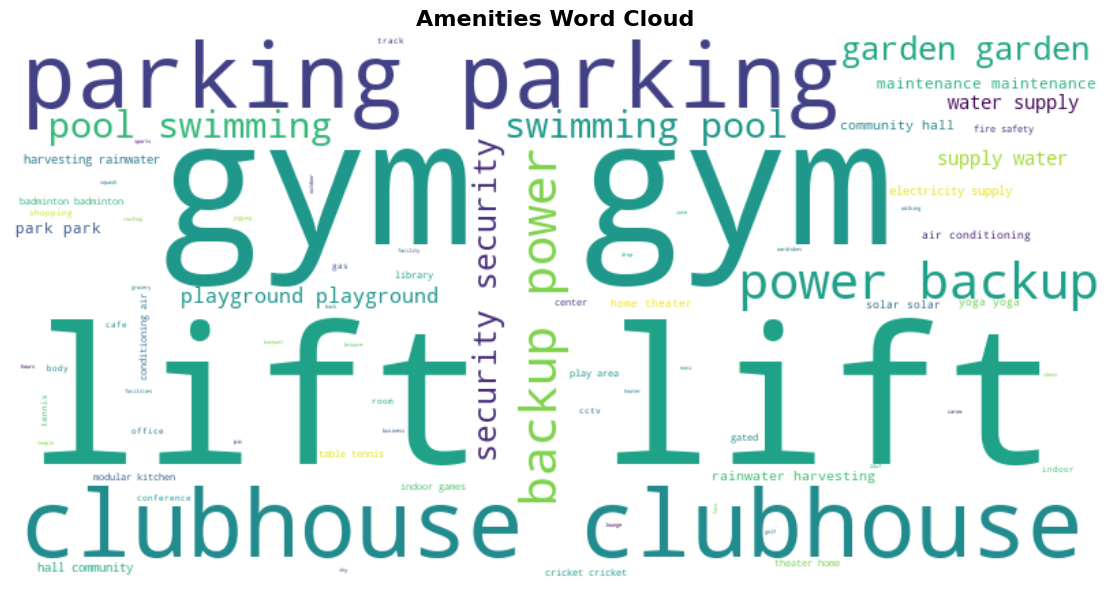


=== Key amenities counts ===
gym: 103
clubhouse: 86
swimming pool: 60
garden: 49
security: 44
parking: 79


In [ ]:
freq_text = """
[]                                                                                                                                    1484
[lift, garden, parking, clubhouse, swimming pool, gym, security, power backup]                                                          10
[lift, gym, security, power backup]                                                                                                      7
[lift]                                                                                                                                   7
[lift, garden, parking, clubhouse, power backup]                                                                                         6
[parking]                                                                                                                                6
[lift, parking]                                                                                                                          5
[lift, garden, parking, security, power backup]                                                                                          5
[swimming pool, fitness centre / gym]                                                                                                    4
[landscaped gardens, childrens play areas, clubhouse, security]                                                                          4
[24 hour water, 24 hour electricity, solar system]                                                                                       3
[fitness center, clubhouse]                                                                                                              3
[visitor parking]                                                                                                                        3
[fitness center]                                                                                                                         3
[lift, power backup, rainwater harvesting]                                                                                               2
[lift, gym, swimming pool]                                                                                                               2
[party plot/garden, common parking area, 24 hr. Water, 24 hr. electricity, pipeline gas connection]                                      2
[gym, indoor games, community hall, home theatre, water body, conference room, working office]                                           2
[fitness center, clubhouse, swimming pool]                                                                                               2
[gym, clubhouse, swimming pool, lift]                                                                                                    2
[gym, clubhouse, pool, power backup]                                                                                                     2
[lift, parking, clubhouse, swimming pool, power backup]                                                                                  2
[lift, fitness center]                                                                                                                   2
[gym, clubhouse, power backup, lift]                                                                                                     2
[lift, swimming pool]                                                                                                                    2
[fitness centre / gym, club house, park, shopping centre, lift(s)]                                                                       2
[swimming pool, fitness centre / gym, club house]                                                                                        2
[visitor parking, on-Call maintenance]                                                                                                   2
[gym, clubhouse, lift]                                                                                                                   2
[swimming pool]                                                                                                                          2
[clubhouse, swimming pool, garden]                                                                                                       2
[swimming pool, lift]                                                                                                                    2
[lift, garden, parking, clubhouse, security, power backup]                                                                               1
[clubhouse, garden, children play area, parking, power backup, security, cctv, pic and drop facility]                                    1
[club house, chi]                                                                                                                        1
[fitness centre / gym, club house, cctv surveillance, lift(s)]                                                                           1
[lift, gym, parking]                                                                                                                     1
[clubhouse, gym, cafe, badminton court, box cricket]                                                                                     1
[garden, gym, indoor play hall, common hall]                                                                                             1
[modular kitchen, wardrobes, parking]                                                                                                    1
[lift, garden, parking, electric geysers, fans, ac, solar panel, power backup]                                                           1
[gym, park, kids play area, tt area, community hall]                                                                                     1
[lift, gym, clubhouse, swimming pool]                                                                                                    1
[lift, parking, clubhouse, garden]                                                                                                       1
[rainwater harvesting, power backup, lift]                                                                                               1
[lift, power backup, rainwater harvesting, clubhouse]                                                                                    1
[lift, clubhouse, fitness center]                                                                                                        1
[gym, yoga room, children play area, community hall]                                                                                     1
[gym, garden, lift]                                                                                                                      1
[community hall, yoga room, garden, children play area]                                                                                  1
[3 car parking, lift, garden]                                                                                                            1
[garden, security, clubhouse]                                                                                                            1
[garden, gym, yoga room, theatre, club house, kids zone]                                                                                 1
[24/7 water, gated society security, visitor parking, on-Call maintenance]                                                               1
[club, power back-Up]                                                                                                                    1
[lift, garden, parking, clubhouse, swimming pool, gym, security, power backup, mini golf course, squash court, cafe]                     1
[swimming pool, gym, yoga room, table tennis room, badminton, children play area, cricket, walking track]                                1
[lift, gym, security]                                                                                                                    1
[swimming pool, fitness centre / gym, park, lift(s)]                                                                                     1
[swimming pool, fitness]                                                                                                                 1
[central ac, parking]                                                                                                                    1
[swimming pool, gym, garden, tennis court, clubhouse, 24x7 security, fire safety]                                                        1
[lift, power backup, childrens play area]                                                                                                1
[lift, fire safety system, 24 hours water supply, security]                                                                              1
[swimming pool, fitness centre / gym, park, club house, cctv surveillance]                                                               1
[gym, clubhouse]                                                                                                                         1
[landscaped gardens, childrens play area, yoga zone, cctv surveillance, gated security, ample parking]                                   1
[sky lounge, clubhouse, landscaped leisure zones]                                                                                        1
[cricket pitch, badminton court, cycling & jogging track, power backup]                                                                  1
[fitness]                                                                                                                                1
[gym, clubhouse, power backup, lift, rainwater harvesting]                                                                               1
[clubhouse, gym, lift, swimming pool]                                                                                                    1
[lift, on-Call maintenance]                                                                                                              1
[gym, rainwater harvesting, power backup, lift]                                                                                          1
[lift, power backup, parking, gym, clubhouse]                                                                                            1
[swimming pool, club house, cctv surveillance, lift(s)]                                                                                  1
[garden]                                                                                                                                 1
[lift, gym, clubhouse, cctv]                                                                                                             1
[lift, power backup, fire safety systems, 247 water supply]                                                                              1
[swimming pool, gym, clubhouse, lift]                                                                                                    1
[gymnasium, children's play area, swimming pool, sports avenues, library, business center, temple]                                       1
[lift, garden, parking, clubhouse]                                                                                                       1
[gym]                                                                                                                                    1
[indoor games, kids play area, 24 hours water supply, security]                                                                          1
[lift, garden, parking]                                                                                                                  1
[lift, gym, rooftop]                                                                                                                     1
[fitness centre / gym, parking, clubhouse, swimming pool]                                                                                1
[lift, gated society]                                                                                                                    1
[clubhouse, lift]                                                                                                                        1
[lift, gym, clubhouse]                                                                                                                   1
[park, lift]                                                                                                                             1
[lift, park]                                                                                                                             1
[lift, garden, park, fitness centre / gym]                                                                                               1
[parking, gated society]                                                                                                                 1
[gym, clubhouse, pool, parking, lift]                                                                                                    1
[gym, pool]                                                                                                                              1
[swimming pool, fitness centre / gym, grocery shop]                                                                                      1
[lift, visitor parking, on-Call maintenance]                                                                                             1
[fitness centre / gym, club house, lift(s)]                                                                                              1
[fitness centre / gym, club house, parking]                                                                                              1
[lift, power backup, parking]                                                                                                            1
[clubhouse, gym, parking]                                                                                                                1
[power backup, visitor parking]                                                                                                          1
[lift, gym, clubhouse, swimming pool, parking]                                                                                           1
[clubhouse, swimming pool, lift, power backup]                                                                                           1
[clubhouse, gym]                                                                                                                         1
[air-conditioned, parking]                                                                                                               1
[lift, gym, clubhouse, swimming pool, power backup]                                                                                      1
[lift, parking, garden]                                                                                                                  1
[lift, clubhouse, gym, swimming pool]                                                                                                    1
[fitness centre / gym]                                                                                                                   1
[clubhouse, gym, lift]                                                                                                                   1
[lift, power backup, central ac]                                                                                                         1
[lift, power backup, visitor parking, on-Call maintenance]                                                                               1
[clubhouse, gym, swimming pool, lift, parking, power backup]                                                                             1
[power backup, clubhouse]                                                                                                                1
[lift, parking, gated society access, on-Call maintenance]                                                                               1
[lift, clubhouse, gym, 24/7 water]                                                                                                       1
[lift, garden, outdoor play area, banquet hall, badminton court, cricket pitch, indoor cinema, indoor play area, library, parking]       1
[lift, gated security, power backup]                                                                                                     1
[clubhouse, gym, lift, pool]                                                                                                             1
[lift, gym, swimming pool, power backup]                                                                                                 1
[gym, swimming pool, lift, power backup]                                                                                                 1
[gym, clubhouse, lift, power backup]                                                                                                     1
[lift, parking, solar system]                                                                                                            1
[power backup, parking]                                                                                                                  1
[lift, cctv surveillance]                                                                                                                1
[lift, gym, clubhouse, parking, swimming pool]                                                                                           1
[parking, gym, clubhouse, lift]                                                                                                          1
[garden, club house, gym]                                                                                                                1
[lift, parking, cctv camera, power backup]                                                                                               1
[full power backup, 24x7 water, on-Call maintenance]                                                                                     1
[swimming pool, gym, tennis, table tennis, carom, ches, library]                                                                         1
[lift, gym, parking, power backup]                                                                                                       1
[parking, power backup]                                                                                                                  1
[gym, swimming pool]                                                                                                                     1
[fitness center, power backup]                                                                                                           1
[car parking facility, 24 hours water]                                                                                                   1
[lift, security, 24x7 water supply]                                                                                                      1
[visitor parking, modular kitchen]                                                                                                       1
[gated security, modular kitchen, 24/7 water]                                                                                            1
"""

# -------------------------------------------------------------
# 2. Robust parsing using regex
# -------------------------------------------------------------
pattern = r'\[(.*?)\]\s+(\d+)'  # captures list content and count
matches = re.findall(pattern, freq_text, re.MULTILINE)

raw_rows = []
total_props = 0

for list_content, count_str in matches:
    count = int(count_str)
    total_props += count
    # Convert list_content string to a proper list
    # Split by commas, strip each item, remove empty
    if list_content.strip() == '':
        items = []
    else:
        items = [item.strip() for item in list_content.split(',')]
    # Add the same list 'count' times
    for _ in range(count):
        raw_rows.append(items)

print(f"Total properties parsed: {total_props}")
print(f"Length of raw_rows: {len(raw_rows)}")
print("First 3 rows (raw):", raw_rows[:3])

# Create new_df
new_df = pd.DataFrame({'raw_amenities': raw_rows})

# -------------------------------------------------------------
# 3. Amenity mapping (same as before, but ensure it's complete)
# -------------------------------------------------------------
amenity_mapping = {
    "lift": "lift", "lift(s)": "lift",
    "garden": "garden", "landscaped gardens": "garden", "party plot/garden": "garden",
    "park": "park", "landscaped leisure zones": "leisure zone",
    "parking": "parking", "visitor parking": "parking", "car parking facility": "parking",
    "common parking area": "parking", "ample parking": "parking", "3 car parking": "parking",
    "clubhouse": "clubhouse", "club house": "clubhouse", "club": "clubhouse",
    "community hall": "community hall", "common hall": "community hall",
    "banquet hall": "banquet hall", "conference room": "conference room",
    "working office": "office", "business center": "business center", "sky lounge": "sky lounge",
    "swimming pool": "swimming pool", "pool": "swimming pool", "water body": "water body",
    "gym": "gym", "fitness center": "gym", "fitness centre / gym": "gym",
    "fitness centre": "gym", "fitness": "gym", "gymnasium": "gym",
    "security": "security", "cctv surveillance": "security", "cctv camera": "security",
    "gated society security": "security", "gated security": "security", "24x7 security": "security",
    "fire safety": "fire safety", "fire safety system": "fire safety", "fire safety systems": "fire safety",
    "power backup": "power backup", "power back-Up": "power backup", "full power backup": "power backup",
    "24 hour water": "water supply", "24 hr. water": "water supply", "24 hours water supply": "water supply",
    "24/7 water": "water supply", "247 water supply": "water supply", "24x7 water supply": "water supply",
    "24 hour electricity": "electricity supply", "24 hr. electricity": "electricity supply",
    "rainwater harvesting": "rainwater harvesting", "solar system": "solar", "solar panel": "solar",
    "pipeline gas connection": "gas",
    "indoor games": "indoor games", "indoor play hall": "indoor play area", "indoor play area": "indoor play area",
    "indoor cinema": "home theater", "table tennis room": "table tennis", "table tennis": "table tennis",
    "tt area": "table tennis", "carom": "carom", "ches": "chess",
    "badminton court": "badminton", "badminton": "badminton", "box cricket": "cricket", "cricket pitch": "cricket",
    "cricket": "cricket", "tennis court": "tennis", "tennis": "tennis", "squash court": "squash",
    "mini golf course": "mini golf", "cycling & jogging track": "jogging track", "walking track": "walking track",
    "childrens play areas": "playground", "childrens play area": "playground", "children play area": "playground",
    "children's play area": "playground", "kids play area": "playground", "kids zone": "playground",
    "yoga room": "yoga", "yoga zone": "yoga",
    "library": "library", "grocery shop": "grocery", "shopping centre": "shopping center", "cafe": "cafe",
    "home theatre": "home theater", "theatre": "home theater", "rooftop": "rooftop",
    "on-call maintenance": "maintenance",
    "modular kitchen": "modular kitchen", "wardrobes": "wardrobes", "electric geysers": "water heater",
    "fans": "fans", "ac": "air conditioning", "central ac": "air conditioning", "air-conditioned": "air conditioning",
    "gated society": "gated community", "gated society access": "gated community",
    "sports avenues": "sports facilities", "temple": "temple", "chi": "other",
}

def normalize_amenities(amenities_list):
    if not amenities_list:
        return []
    normalized = set()
    for item in amenities_list:
        item = str(item).strip().lower()
        mapped = amenity_mapping.get(item, item)
        # Keep only meaningful amenities (skip 'other' or empty)
        if mapped and mapped != 'other':
            normalized.add(mapped)
    return list(normalized)

new_df['normalized_amenities'] = new_df['raw_amenities'].apply(normalize_amenities)

# Show a sample
print("\nSample after normalization:")
print(new_df[['raw_amenities', 'normalized_amenities']].head(10))

# -------------------------------------------------------------
# 4. Count all amenities
# -------------------------------------------------------------
all_amenities = []
for lst in new_df['normalized_amenities']:
    all_amenities.extend(lst)
amenity_counter = Counter(all_amenities)

print(f"\nTotal unique amenities: {len(amenity_counter)}")
if len(amenity_counter) == 0:
    print("ERROR: No amenities found. Check your mapping and raw data.")
else:
    print("\nTop 20 amenities by count:")
    for amenity, cnt in amenity_counter.most_common(20):
        print(f"{amenity}: {cnt}")

# -------------------------------------------------------------
# 5. Word cloud
# -------------------------------------------------------------
if len(amenity_counter) > 0:
    # Create string with repeated words according to count
    word_string = ' '.join([amenity for amenity, cnt in amenity_counter.items() for _ in range(cnt)])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis',
                          max_words=100, contour_width=1, contour_color='steelblue').generate(word_string)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Amenities Word Cloud', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot generate word cloud: no amenities found.")

# -------------------------------------------------------------
# 6. Specific amenities (gym, clubhouse, etc.)
# -------------------------------------------------------------
key_amenities = ['gym', 'clubhouse', 'swimming pool', 'garden', 'security', 'parking']
print("\n=== Key amenities counts ===")
for k in key_amenities:
    print(f"{k}: {amenity_counter.get(k, 0)}")

In [ ]:
print("\n=== Full list of 58 amenities with frequencies ===\n")
for i, (amenity, count) in enumerate(sorted(amenity_counter.items(), key=lambda x: x[1], reverse=True), 1):
    print(f"{i:2}. {amenity:<20} {count}")


=== Full list of 58 amenities with frequencies ===

 1. lift                 122
 2. gym                  103
 3. clubhouse            86
 4. parking              79
 5. power backup         66
 6. swimming pool        60
 7. garden               49
 8. security             44
 9. playground           14
10. water supply         12
11. park                 8
12. maintenance          8
13. rainwater harvesting 6
14. community hall       6
15. solar                5
16. electricity supply   5
17. yoga                 5
18. home theater         4
19. badminton            4
20. cricket              4
21. air conditioning     4
22. indoor games         3
23. modular kitchen      3
24. table tennis         3
25. fire safety          3
26. library              3
27. gated community      3
28. gas                  2
29. office               2
30. conference room      2
31. water body           2
32. shopping center      2
33. cctv                 2
34. cafe                 2
35. indoor play a

C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_14512\2699080046.py:56: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0)
c:\Users\MEGH BAVARVA\Desktop\Data Scientist\Project\Real_Estate\Code\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


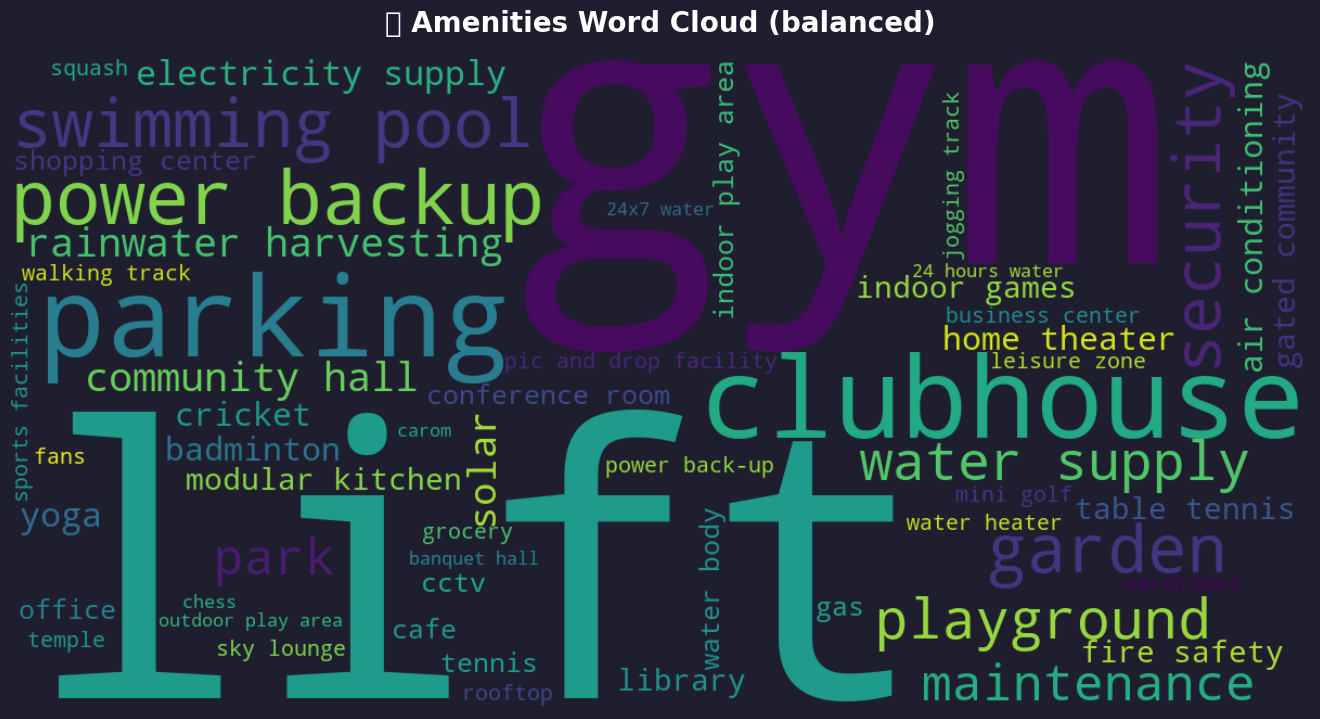

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

# Your amenity frequencies (from your output)
amenity_freq = {
    'lift': 122, 'gym': 103, 'clubhouse': 86, 'parking': 79, 'power backup': 66,
    'swimming pool': 60, 'garden': 49, 'security': 44, 'playground': 14,
    'water supply': 12, 'park': 8, 'maintenance': 8, 'rainwater harvesting': 6,
    'community hall': 6, 'solar': 5, 'electricity supply': 5, 'yoga': 5,
    'home theater': 4, 'cricket': 4, 'badminton': 4, 'air conditioning': 4,
    'indoor games': 3, 'modular kitchen': 3, 'table tennis': 3, 'fire safety': 3,
    'library': 3, 'gated community': 3, 'gas': 2, 'office': 2, 'conference room': 2,
    'water body': 2, 'shopping center': 2, 'cctv': 2, 'cafe': 2, 'indoor play area': 2,
    'tennis': 2, 'pic and drop facility': 1, 'wardrobes': 1, 'fans': 1,
    'water heater': 1, 'power back-up': 1, 'mini golf': 1, 'squash': 1,
    'walking track': 1, 'sky lounge': 1, 'leisure zone': 1, 'jogging track': 1,
    'temple': 1, 'business center': 1, 'sports facilities': 1, 'rooftop': 1,
    'grocery': 1, 'outdoor play area': 1, 'banquet hall': 1, '24x7 water': 1,
    'carom': 1, 'chess': 1, '24 hours water': 1
}

# Apply log transformation to reduce dominance of high-frequency words
# We'll use log(1 + count) – works well for skewed data
log_freq = {word: np.log1p(cnt) for word, cnt in amenity_freq.items()}

# Background color (dark for contrast on white website)
bg_color = '#1e1e2f'

# Generate word cloud from log-transformed frequencies
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color=bg_color,
    colormap='viridis',          # vibrant colours
    max_words=80,                # show top 80 terms
    relative_scaling=0.5,        # less aggressive scaling
    contour_width=1,
    contour_color='white',
    random_state=42
).generate_from_frequencies(log_freq)   # using log frequencies

# Display
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('white')
    spine.set_linewidth(0.5)

plt.title('🏠 Amenities Word Cloud (balanced)', fontsize=20, fontweight='bold',
          color='white', pad=20, backgroundcolor=bg_color)
plt.tight_layout(pad=0)
plt.show()



Total nearby properties parsed: 1695
Rows in raw_df: 1695
First 3 rows: [[], [], []]

Total unique nearby places: 100

Top 20 nearby places by frequency:
hospital: 228
school: 190
metro: 115
mall: 93
temple: 93
highway: 89
market: 51
gift city: 29
office: 20
clinic: 15
university: 12
railway: 11
road: 10
randheja railway station: 6
airport: 5
garden: 5
bus: 5
gandhinagar: 4
atm: 4
key religious sites: 4


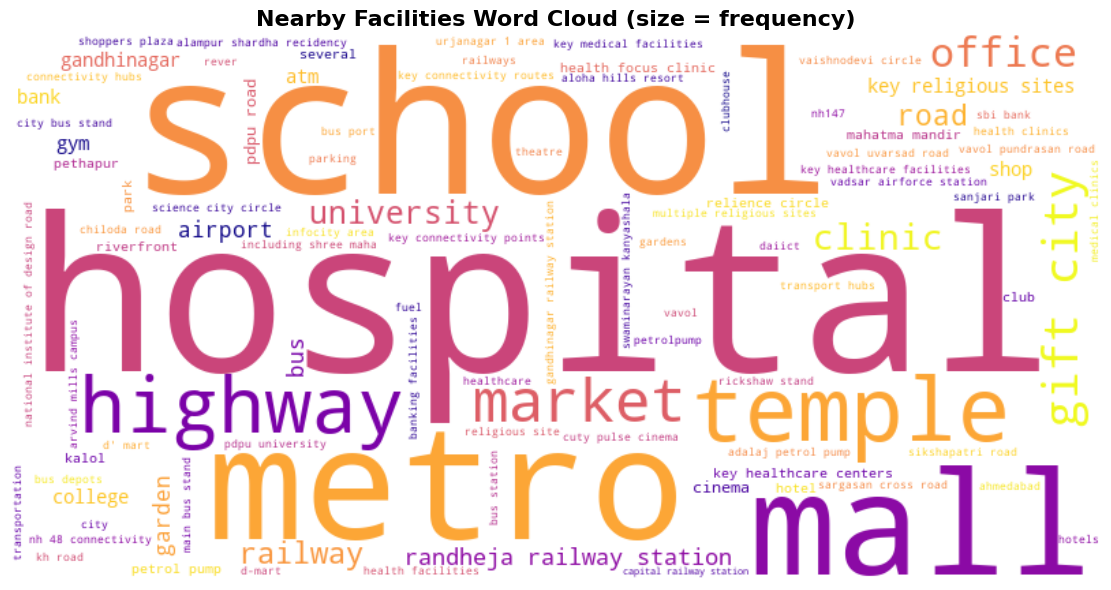

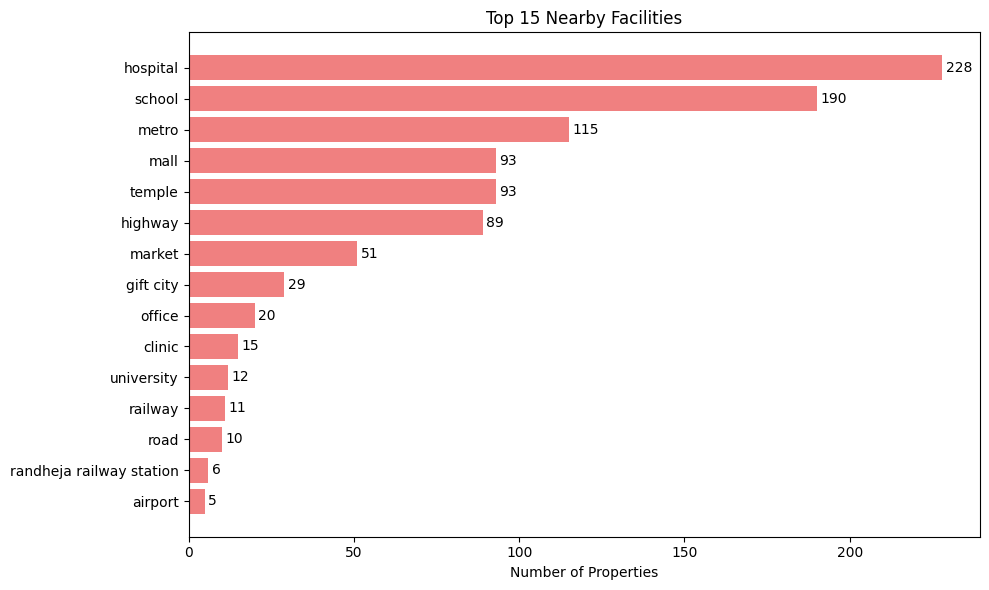

In [ ]:
nearby_freq_text = """
[]                                                                                                                      1247
[school, hospital, metro, mall, highway]                                                                                  35
[school]                                                                                                                  19
[metro]                                                                                                                   12
[school, hospital, metro]                                                                                                 11
[school, hospital]                                                                                                        10
[hospital]                                                                                                                 9
[highway]                                                                                                                  9
[hospitals, ambe mata mandir]                                                                                              8
[school, hospital, mall, highway]                                                                                          7
[temple, hospital]                                                                                                         7
[gift city]                                                                                                                6
[metro station, gift city]                                                                                                 6
[hospitals]                                                                                                                5
[gift city, metro station]                                                                                                 5
[temples, hospitals]                                                                                                       4
[temple]                                                                                                                   4
[school, hospital, market]                                                                                                 4
[school, markets]                                                                                                          4
[podar international]                                                                                                      4
[sheth n.N saravajanik hospital, randheja railway station]                                                                 4
[schools, hospitals]                                                                                                       3
[sg highway]                                                                                                               3
[hospital, temple]                                                                                                         3
[hospitals, shree satay narayan mandir]                                                                                    3
[12 meter road]                                                                                                            3
[relience circle]                                                                                                          2
[s p ring road]                                                                                                            2
[hospitals, infocity]                                                                                                      2
[schools, hospital, shopping]                                                                                              2
[mall, school]                                                                                                             2
[gandhinagar, kalol]                                                                                                       2
[pdpu metro, national highway 48]                                                                                          2
[temples, healthcare facilities]                                                                                           2
[religious landmarks, several]                                                                                             2
[school, market]                                                                                                           2
[shri hanumanji temple, multiple hospitals]                                                                                2
[hospitals, schools, markets]                                                                                              2
[hospital, school]                                                                                                         2
[hospitals, temple]                                                                                                        2
[religious sites]                                                                                                          2
[metro, malls, schools]                                                                                                    2
[school, hospital, mall]                                                                                                   2
[highway, mall]                                                                                                            2
[health focus physiotherapy clinic, infocity, pandit deendayal petroleum university]                                       2
[metro station, hospital]                                                                                                  2
[metro, school]                                                                                                            2
[hospital, railway station]                                                                                                2
[metro, road, highway]                                                                                                     1
[key connectivity points, schools]                                                                                         1
[hospitals, schools, markets, khodiyar temple, bank of baroda atm]                                                         1
[key religious sites, medical facilities]                                                                                  1
[metro, malls, schools, highways]                                                                                          1
[metro, market, pdpu, swaminarayan kanyashala, cuty pulse cinema, temples, svms hospital]                                  1
[hospitals, clubhouse]                                                                                                     1
[metro, religious sites]                                                                                                   1
[top schools, hospitals, sarkhej gandhinagar highway]                                                                      1
[health focus physiotherapy clinic, infocity]                                                                              1
[school, airport, shopping]                                                                                                1
[school, hospital, university]                                                                                             1
[schools, market, main road]                                                                                               1
[school, hotel, mall]                                                                                                      1
[schools, markets, hospitals]                                                                                              1
[sanjari park, pethapur]                                                                                                   1
[markets, metro, schools, railways]                                                                                        1
[hospitals, supreme smile dental clinic, gayatri hospital]                                                                 1
[prominent temples, multispeciality clinic]                                                                                1
[hospital, mall, railway station]                                                                                          1
[religious sites, multispecialty clinic]                                                                                   1
[multiple temples, dental clinic]                                                                                          1
[swaminarayan temple, gayatri hospital]                                                                                    1
[schools, hospital, mall, highway]                                                                                         1
[temples, medical facilities]                                                                                              1
[khodiyar temple, medical facilities, atms]                                                                                1
[hospitals, shr hanumanji temple]                                                                                          1
[bus depots, school]                                                                                                       1
[key healthcare facilities, infocity office complex]                                                                       1
[metro, highway]                                                                                                           1
[hospitals, infocity office complex]                                                                                       1
[pdpu road, gift city, metro station]                                                                                      1
[koba circle metro, schools, nh 48, esic hospital]                                                                         1
[nh147, sahjanand school, shoppers plaza]                                                                                  1
[multiple religious sites, shree mahakali mataji temple, swaminarayan temple]                                              1
[school, shopping malls, hospitals, garden]                                                                                1
[metro, hospitals, office complexes]                                                                                       1
[tcs, software company offices]                                                                                            1
[schools, hospital, shopping at swagat holiday mall]                                                                       1
[temples, clinics]                                                                                                         1
[multiple hospitals, health focus physiotherapy clinic]                                                                    1
[sg highway, adalaj petrol pump]                                                                                           1
[several temples]                                                                                                          1
[metro, schools]                                                                                                           1
[ramdevpir temple, Pethapur, gandhinagar]                                                                                  1
[tech parks, infocity, gift city, s.G. Highway, swagat holiday mall, dmart]                                                1
[sg highway, daiict, aashka hospital]                                                                                      1
[sbi bank, temple, market, school, rickshaw stand]                                                                         1
[railway station, medical college hospital, city bus stand]                                                                1
[school, hospital, highway, mall]                                                                                          1
[school, hospital, bus stop, highway]                                                                                      1
[relience smart bazar]                                                                                                     1
[science city circle]                                                                                                      1
[hospital, school, malls]                                                                                                  1
[poddar international school]                                                                                              1
[vavol pundrasan road]                                                                                                     1
[city pulse cinema, urjanagar 1 area]                                                                                      1
[S.G highway]                                                                                                              1
[pdpu road]                                                                                                                1
[sargasan cross road]                                                                                                      1
[d' mart]                                                                                                                  1
[mall, school, hospital]                                                                                                   1
[infocity area, national institute of design road]                                                                         1
[kh road]                                                                                                                  1
[club house]                                                                                                               1
[markets, hospital, school, malls]                                                                                         1
[schools, markets]                                                                                                         1
[metro station, school, hospital, highway]                                                                                 1
[school, mall, temple, garden]                                                                                             1
[school, hospital, shopping mall]                                                                                          1
[school, shopping malls]                                                                                                   1
[school, hospital, metro, mall, highway, airport, park]                                                                    1
[metro, rever]                                                                                                             1
[school, hospital, bazaar]                                                                                                 1
[schools, healthcare, shri hanumanji temple]                                                                               1
[temple, dental clinic]                                                                                                    1
[key medical facilities, gandhinagar]                                                                                      1
[railway station, metro station, mall, market]                                                                             1
[swaminarayan temple, hospitals]                                                                                           1
[malls, highways]                                                                                                          1
[hospitals, religious sites]                                                                                               1
[schools, hospitals, banks]                                                                                                1
[metro, market, hospital, school]                                                                                          1
[shopping malls, highways]                                                                                                 1
[school, shopping hubs]                                                                                                    1
[schools, malls, connectivity hubs]                                                                                        1
[highway, mall, companies]                                                                                                 1
[hospitals, religious site]                                                                                                1
[key hospitals, shree satay narayan mandir]                                                                                1
[school, vegetable market, temple, railway station, bus port]                                                              1
[khodiyar temple, bank of baroda atm, hospitals]                                                                           1
[key temples, healthcare centers]                                                                                          1
[hospital, school, market]                                                                                                 1
[vachhani hospital, kroma multispeciality dental clinic]                                                                   1
[health clinics, infocity office complex, pandit deendayal petroleum university]                                           1
[city, highway, shopping centre]                                                                                           1
[amenities]                                                                                                                1
[temples, clinics, fitness center]                                                                                         1
[mini market, sikshapatri road, vaishnodevi circle, gift city]                                                             1
[healthcare facilities, Pandit Deendayal Petroleum University]                                                             1
[malls, highway]                                                                                                           1
[hospital, market, metro station]                                                                                          1
[hospital, garden]                                                                                                         1
[metro, school, hospital, market]                                                                                          1
[mahudi tirth jain temple, mahudi jain temple]                                                                             1
[schools, malls, nh 48 connectivity]                                                                                       1
[IIT Gandhinagar, Gift City Circle]                                                                                        1
[super mall, reputed schools, shraddha womens hospital]                                                                    1
[highway, bus stand, vegetable market, hotels]                                                                             1
[metro, airport]                                                                                                           1
[gayatri mandir, hospitals]                                                                                                1
[key healthcare centers, infocity office complex]                                                                          1
[temple, medical hospital]                                                                                                 1
[metro station, malls, gardens, mahatma mandir, railway station, main road, school, college, hospital, market place]       1
[key religious sites, healthcare facilities]                                                                               1
[mall, educational institutions]                                                                                           1
[metro, schools, hospitals, markets]                                                                                       1
[school, market, hospital]                                                                                                 1
[ambe mata mandir, hospital]                                                                                               1
[religious facilities, healthcare facilities]                                                                              1
[health facilities, infocity]                                                                                              1
[metro, schools, hospitals, markets, temples]                                                                              1
[gift city, s.G. Highway]                                                                                                  1
[metro station, school]                                                                                                    1
[school, hospital, railway station, market]                                                                                1
[super mall 1, educational institutes]                                                                                     1
[hotel, school, hospital]                                                                                                  1
[sheth n.N saravajanik hospital, market, school, randheja railway station]                                                 1
[prominent temples]                                                                                                        1
[metro station]                                                                                                            1
[hospitals, markets, schools, fitness center]                                                                              1
[general stores]                                                                                                           1
[shopping, educational hubs]                                                                                               1
[temples, medical clinics]                                                                                                 1
[vavol uvarsad road, vavol]                                                                                                1
[hospital, market, railway station]                                                                                        1
[metro, school, gift city]                                                                                                 1
[hospitals, markets, schools]                                                                                              1
[swaminarayan temple, hospital]                                                                                            1
[vadsar airforce station, arvind mills campus]                                                                             1
[hospital, mall]                                                                                                           1
[metro, school, hospital, mall, highway]                                                                                   1
[religious sites, hospital]                                                                                                1
[swaminarayan akshardham temple, hospitals]                                                                                1
[khodiyar temple, hospital, bank of baroda atm]                                                                            1
[hospitals, swaminarayan akshardham temple]                                                                                1
[sg highway, baps temple, market]                                                                                          1
[ioc facilities]                                                                                                           1
[swagat holiday mall, gift city]                                                                                           1
[hospitals, bus depot, ring road]                                                                                          1
[school, hospital, garden, temple, metro, railway station, airport]                                                        1
[renowned temples]                                                                                                         1
[multiple temples]                                                                                                         1
[gnlu metro, school]                                                                                                       1
[swaminarayan akshardham temple]                                                                                           1
[metro, airport, railway station]                                                                                          1
[sg highway, swaminarayan temple, gayatri mandir, radhe children hospital]                                                 1
[key religious sites, sanjivani heart and medical hospital]                                                                1
[mall, highway, school]                                                                                                    1
[mall, highway]                                                                                                            1
[pdpu metro, major schools]                                                                                                1
[key healthcare centers, pdpu university, metro station, mall, office complexes]                                           1
[religious temples]                                                                                                        1
[gift city, dhirubhai ambani university, nift, nid, tcs, infocity, metro station]                                          1
[school, garden, shopping mall, highway]                                                                                   1
[school, gift city]                                                                                                        1
[gift city, markets]                                                                                                       1
[gandhinagar railway station]                                                                                              1
[super mall, schools, hospital]                                                                                            1
[khodiyar temple, banks, healthcare facilities]                                                                            1
[swaminarayan akshardham temple, hospital]                                                                                 1
[hospitals, swaminarayan temple]                                                                                           1
[vadaj metro, schools, malls]                                                                                              1
[school, hospital, bank, petrolpump]                                                                                       1
[petrol pump, school]                                                                                                      1
[hospitals, parking]                                                                                                       1
[renowned temples, medical facilities]                                                                                     1
[Brts]                                                                                                                     1
[university, highway]                                                                                                      1
[school, hospital, bus stand, temple]                                                                                      1
[mall, cinema, hospital, schools, markets]                                                                                 1
[health focus physiotherapy clinic, infocity office complex, pandit deendayal petroleum university]                        1
[mall]                                                                                                                     1
[schools, hospitals, transport hubs]                                                                                       1
[road]                                                                                                                     1
[highway, theatre]                                                                                                         1
[top schools, hospitals]                                                                                                   1
[school, college, market, bus station, hospital, park, gym, cinema, mall]                                                  1
[super mall 1, nh 48, top schools, apollo hospital]                                                                        1
[chiloda road, apmc market, alampur Shardha recidency]                                                                     1
[market, school, hospital]                                                                                                 1
[metro, market, hospitals]                                                                                                 1
[school, hospital, markets]                                                                                                1
[mall, dmart]                                                                                                              1
[metro, hospital, college]                                                                                                 1
[river front]                                                                                                              1
[civil hospital, main bus stand]                                                                                           1
[banks, schools, hospitals]                                                                                                1
[petrol pump, pdpu road, koba-Gandhinagar highway]                                                                         1
[religious sites, including shree maha]                                                                                    1
[clinics, infocity, pandit deendayal petroleum university]                                                                 1
[shops]                                                                                                                    1
[gift city rivera front, randesan metro station]                                                                           1
[school, shops, transportation]                                                                                            1
[infocity, health focus clinic]                                                                                            1
[mahudi temple, aloha hills resort]                                                                                        1
[school, hospital, gym, club]                                                                                              1
[key connectivity routes, ahmedabad, gift city]                                                                            1
[Metro, Hospital, Riverfront]                                                                                              1
[Metro, market]                                                                                                            1
[khodiyar temple, hospitals, banking facilities]                                                                           1
[infocity, health focus clinic, pandit deendayal petroleum university]                                                     1
[key religious sites, hospitals]                                                                                           1
[religious landmarks, metro]                                                                                               1
[randheja railway station, sheth n.N saravajanik hospital]                                                                 1
[mahatma mandir, capital railway station, reliance mall, d-Mart]                                                           1
"""

# -------------------------------------------------------------
# 2. Parse using regex
# -------------------------------------------------------------
pattern = r'\[(.*?)\]\s+(\d+)'
matches = re.findall(pattern, nearby_freq_text, re.MULTILINE)

raw_rows = []
total_props = 0

for list_content, count_str in matches:
    count = int(count_str)
    total_props += count
    if list_content.strip() == '':
        items = []
    else:
        # Split by commas, strip each item, keep as is (will normalize later)
        items = [item.strip() for item in list_content.split(',')]
    for _ in range(count):
        raw_rows.append(items)

print(f"Total nearby properties parsed: {total_props}")
print(f"Rows in raw_df: {len(raw_rows)}")
print("First 3 rows:", raw_rows[:3])

# Create new_df
new_df = pd.DataFrame({'raw_nearby': raw_rows})

# -------------------------------------------------------------
# 3. Normalize nearby place names (fix plurals, variations)
# -------------------------------------------------------------
nearby_mapping = {
    # Schools & Education
    'school': 'school',
    'schools': 'school',
    'podar international': 'school',
    'poddar international school': 'school',
    'educational institutes': 'school',
    'educational institutions': 'school',
    'educational hubs': 'school',
    'reputed schools': 'school',
    'top schools': 'school',
    'major schools': 'school',
    'university': 'university',
    'pdpu': 'university',
    'pandit deendayal petroleum university': 'university',
    'dhirubhai ambani university': 'university',
    'nift': 'college',
    'nid': 'college',
    'iit gandhinagar': 'university',
    'college': 'college',
    
    # Hospitals & Healthcare
    'hospital': 'hospital',
    'hospitals': 'hospital',
    'healthcare facilities': 'hospital',
    'medical facilities': 'hospital',
    'medical hospital': 'hospital',
    'multispeciality clinic': 'clinic',
    'dental clinic': 'clinic',
    'health clinic': 'clinic',
    'clinics': 'clinic',
    'apollo hospital': 'hospital',
    'esic hospital': 'hospital',
    'civil hospital': 'hospital',
    'gayatri hospital': 'hospital',
    'svms hospital': 'hospital',
    'aashka hospital': 'hospital',
    'radhe children hospital': 'hospital',
    'sanjivani heart and medical hospital': 'hospital',
    'sheth n.n saravajanik hospital': 'hospital',
    'vachhani hospital': 'hospital',
    'health focus physiotherapy clinic': 'clinic',
    'kroma multispeciality dental clinic': 'clinic',
    'supreme smile dental clinic': 'clinic',
    'multispecialty clinic': 'clinic',
    'healthcare centers': 'clinic',
    'medical college hospital': 'hospital',
    
    # Metro & Transport
    'metro': 'metro',
    'metro station': 'metro',
    'railway station': 'railway',
    'bus stand': 'bus',
    'bus stop': 'bus',
    'bus depot': 'bus',
    'airport': 'airport',
    'highway': 'highway',
    'national highway 48': 'highway',
    'nh 48': 'highway',
    'sarkhej gandhinagar highway': 'highway',
    'sg highway': 'highway',
    's.G. highway': 'highway',
    's p ring road': 'road',
    'ring road': 'road',
    'main road': 'road',
    '12 meter road': 'road',
    'road': 'road',
    'brts': 'bus',
    
    # Shopping & Malls
    'mall': 'mall',
    'malls': 'mall',
    'shopping mall': 'mall',
    'shopping malls': 'mall',
    'shopping centre': 'mall',
    'shopping hubs': 'mall',
    'super mall': 'mall',
    'reliance mall': 'mall',
    'swagat holiday mall': 'mall',
    'd mart': 'mall',
    'dmart': 'mall',
    'market': 'market',
    'markets': 'market',
    'vegetable market': 'market',
    'apmc market': 'market',
    'shopping': 'market',
    'bazaar': 'market',
    
    # Religious places
    'temple': 'temple',
    'temples': 'temple',
    'mandir': 'temple',
    'swaminarayan temple': 'temple',
    'swaminarayan akshardham temple': 'temple',
    'shri hanumanji temple': 'temple',
    'khodiyar temple': 'temple',
    'shree satay narayan mandir': 'temple',
    'gayatri mandir': 'temple',
    'baps temple': 'temple',
    'mahudi jain temple': 'temple',
    'ambe mata mandir': 'temple',
    'religious sites': 'temple',
    'religious landmarks': 'temple',
    'religious facilities': 'temple',
    
    # Offices & Business
    'infocity': 'office',
    'infocity office complex': 'office',
    'office complexes': 'office',
    'tech parks': 'office',
    'tcs': 'office',
    'software company offices': 'office',
    'companies': 'office',
    'business center': 'office',
    'gift city': 'gift city',
    'gift city circle': 'gift city',
    
    # Parks & Recreation
    'garden': 'garden',
    'park': 'park',
    'river front': 'riverfront',
    'rivera front': 'riverfront',
    'cinema': 'cinema',
    'city pulse cinema': 'cinema',
    'club house': 'club',
    'gym': 'gym',
    'fitness center': 'gym',
    
    # Banks & ATMs
    'bank': 'bank',
    'banks': 'bank',
    'bank of baroda atm': 'atm',
    'atm': 'atm',
    'atms': 'atm',
    
    # Misc
    'petrol pump': 'petrol pump',
    'hotel': 'hotel',
    'shops': 'shop',
    'general stores': 'shop',
    'relience smart bazar': 'shop',
    'ioc facilities': 'fuel',
    'dental clinic': 'clinic',  # already above
    'parking': 'parking',
    'amenities': 'other',
    'chi': 'other',
}

def normalize_nearby(items_list):
    if not items_list:
        return []
    normalized = set()
    for item in items_list:
        item = item.strip().lower()
        # Remove any trailing/leading punctuation
        item = item.strip('.,!?')
        # Check mapping (exact or partial)
        mapped = nearby_mapping.get(item, None)
        if mapped is None:
            # Try to find if item contains any key (e.g., "metro station, gift city" -> split later)
            # But we already split by comma. For compound like "gift city rivera front", we treat as separate?
            # We'll keep as is for now, but add mapping for common compounds.
            if 'gift city' in item:
                mapped = 'gift city'
            elif 'metro' in item:
                mapped = 'metro'
            elif 'hospital' in item:
                mapped = 'hospital'
            elif 'school' in item:
                mapped = 'school'
            elif 'temple' in item:
                mapped = 'temple'
            elif 'highway' in item:
                mapped = 'highway'
            elif 'mall' in item:
                mapped = 'mall'
            elif 'market' in item:
                mapped = 'market'
            else:
                mapped = item  # keep original if not found
        if mapped and mapped != 'other':
            normalized.add(mapped)
    return list(normalized)

new_df['normalized_nearby'] = new_df['raw_nearby'].apply(normalize_nearby)

# -------------------------------------------------------------
# 4. Count all nearby place occurrences
# -------------------------------------------------------------
all_nearby = []
for lst in new_df['normalized_nearby']:
    all_nearby.extend(lst)
nearby_counter = Counter(all_nearby)

print("\nTotal unique nearby places:", len(nearby_counter))
print("\nTop 20 nearby places by frequency:")
for place, cnt in nearby_counter.most_common(20):
    print(f"{place}: {cnt}")

# -------------------------------------------------------------
# 5. Word cloud from frequencies
# -------------------------------------------------------------
if len(nearby_counter) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap='plasma', max_words=100,
                          relative_scaling=0.5).generate_from_frequencies(nearby_counter)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nearby Facilities Word Cloud (size = frequency)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No nearby facilities found to generate word cloud.")

# -------------------------------------------------------------
# 6. Bar chart for top 15
# -------------------------------------------------------------
top15 = nearby_counter.most_common(15)
names, counts = zip(*top15)
plt.figure(figsize=(10, 6))
plt.barh(names, counts, color='lightcoral')
plt.xlabel('Number of Properties')
plt.title('Top 15 Nearby Facilities')
plt.gca().invert_yaxis()
for i, v in enumerate(counts):
    plt.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 7. Store the normalized data back to new_df (optional)
# -------------------------------------------------------------
# new_df now has 'raw_nearby' and 'normalized_nearby' columns
# You can save to CSV if needed:
# new_df.to_csv('nearby_data.csv', index=False)

In [ ]:
# -------------------------------------------------------------
# 8. Print all 100 unique nearby places with frequencies
# -------------------------------------------------------------

print("\n" + "="*50)
print("FULL LIST OF 100 UNIQUE NEARBY PLACES (sorted by frequency)")
print("="*50)

# Sort counter items by frequency descending
sorted_nearby = sorted(nearby_counter.items(), key=lambda x: x[1], reverse=True)

# Print numbered list
for i, (place, count) in enumerate(sorted_nearby, 1):
    print(f"{i:3}. {place:<20} {count}")

# Optional: Create a DataFrame for further analysis
nearby_df = pd.DataFrame(sorted_nearby, columns=['Nearby_Place', 'Frequency'])
print("\nDataFrame shape:", nearby_df.shape)
print(nearby_df.head(10))


FULL LIST OF 100 UNIQUE NEARBY PLACES (sorted by frequency)
  1. hospital             228
  2. school               190
  3. metro                115
  4. mall                 93
  5. temple               93
  6. highway              89
  7. market               51
  8. gift city            29
  9. office               20
 10. clinic               15
 11. university           12
 12. railway              11
 13. road                 10
 14. randheja railway station 6
 15. airport              5
 16. garden               5
 17. bus                  5
 18. gandhinagar          4
 19. atm                  4
 20. key religious sites  4
 21. shop                 4
 22. bank                 4
 23. gym                  4
 24. college              4
 25. pdpu road            3
 26. cinema               3
 27. relience circle      2
 28. kalol                2
 29. several              2
 30. hotel                2
 31. pethapur             2
 32. club                 2
 33. park              

C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_14512\369205750.py:65: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0)
c:\Users\MEGH BAVARVA\Desktop\Data Scientist\Project\Real_Estate\Code\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


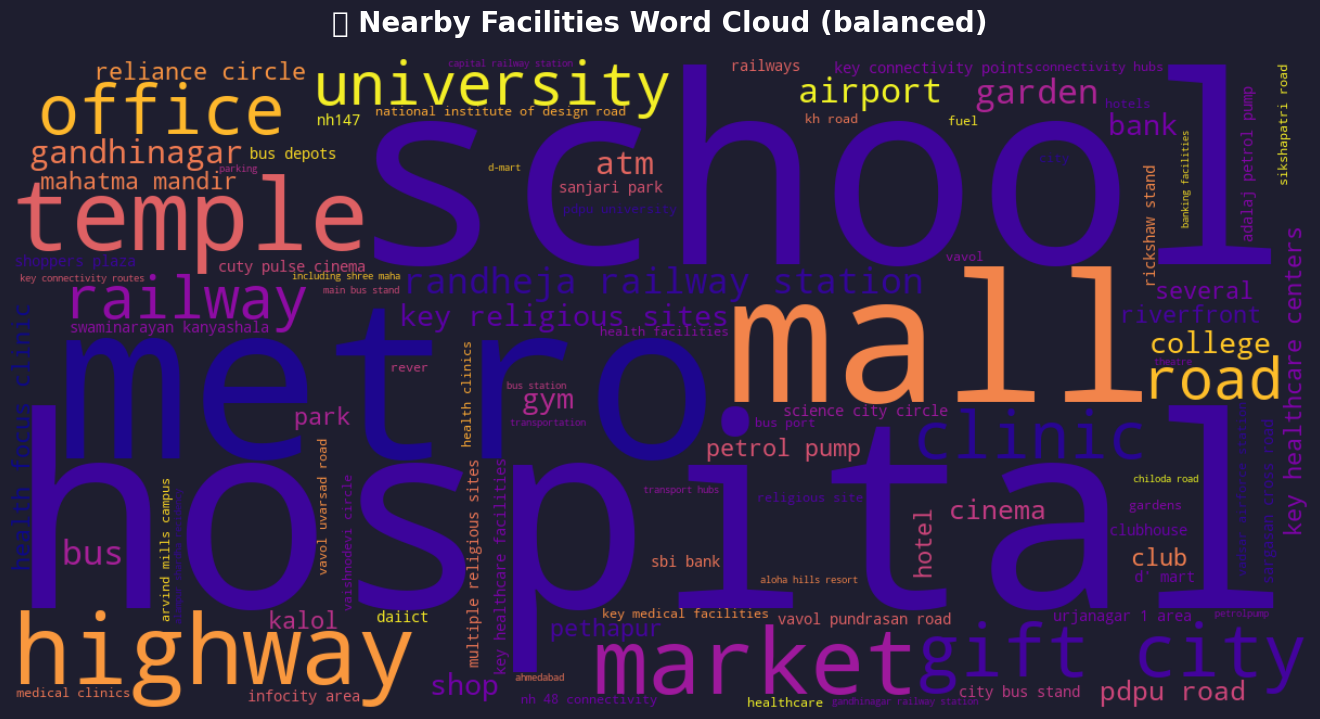

In [ ]:

# Your nearby facility frequencies (copied from your output)
nearby_freq = {
    'hospital': 228, 'school': 190, 'metro': 115, 'mall': 93, 'temple': 93,
    'highway': 89, 'market': 51, 'gift city': 29, 'office': 20, 'clinic': 15,
    'university': 12, 'railway': 11, 'road': 10, 'randheja railway station': 6,
    'airport': 5, 'garden': 5, 'bus': 5, 'gandhinagar': 4, 'atm': 4,
    'key religious sites': 4, 'shop': 4, 'bank': 4, 'gym': 4, 'college': 4,
    'pdpu road': 3, 'cinema': 3, 'reliance circle': 2, 'kalol': 2, 'several': 2,
    'hotel': 2, 'pethapur': 2, 'club': 2, 'park': 2, 'key healthcare centers': 2,
    'mahatma mandir': 2, 'petrol pump': 2, 'riverfront': 2, 'health focus clinic': 2,
    'key connectivity points': 1, 'cuty pulse cinema': 1, 'swaminarayan kanyashala': 1,
    'clubhouse': 1, 'sanjari park': 1, 'railways': 1, 'bus depots': 1,
    'key healthcare facilities': 1, 'shoppers plaza': 1, 'nh147': 1,
    'multiple religious sites': 1, 'adalaj petrol pump': 1, 'daiict': 1,
    'rickshaw stand': 1, 'sbi bank': 1, 'city bus stand': 1, 'science city circle': 1,
    'vavol pundrasan road': 1, 'urjanagar 1 area': 1, 'sargasan cross road': 1,
    "d' mart": 1, 'infocity area': 1, 'national institute of design road': 1,
    'kh road': 1, 'rever': 1, 'healthcare': 1, 'key medical facilities': 1,
    'connectivity hubs': 1, 'religious site': 1, 'bus port': 1, 'health clinics': 1,
    'city': 1, 'sikshapatri road': 1, 'vaishnodevi circle': 1, 'nh 48 connectivity': 1,
    'hotels': 1, 'gardens': 1, 'health facilities': 1, 'medical clinics': 1,
    'vavol': 1, 'vavol uvarsad road': 1, 'vadsar airforce station': 1,
    'arvind mills campus': 1, 'fuel': 1, 'pdpu university': 1,
    'gandhinagar railway station': 1, 'petrolpump': 1, 'parking': 1,
    'transport hubs': 1, 'theatre': 1, 'bus station': 1,
    'alampur shardha recidency': 1, 'chiloda road': 1, 'main bus stand': 1,
    'including shree maha': 1, 'transportation': 1, 'aloha hills resort': 1,
    'ahmedabad': 1, 'key connectivity routes': 1, 'banking facilities': 1,
    'd-mart': 1, 'capital railway station': 1
}

# Apply log transform to reduce dominance of high-frequency words
log_nearby_freq = {word: np.log1p(cnt) for word, cnt in nearby_freq.items()}

# Dark background to stand out on white website
bg_color = '#1e1e2f'

# Generate word cloud using log frequencies
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color=bg_color,
    colormap='plasma',          # warm, vibrant colors
    max_words=120,
    relative_scaling=0.5,       # reduces size disparity
    contour_width=1,
    contour_color='white',
    random_state=42
).generate_from_frequencies(log_nearby_freq)

# Display with matching background and border
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('white')
    spine.set_linewidth(0.5)

plt.title('📍 Nearby Facilities Word Cloud (balanced)', fontsize=20, fontweight='bold',
          color='white', pad=20, backgroundcolor=bg_color)
plt.tight_layout(pad=0)
plt.show()


C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_14512\1135403934.py:67: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0)


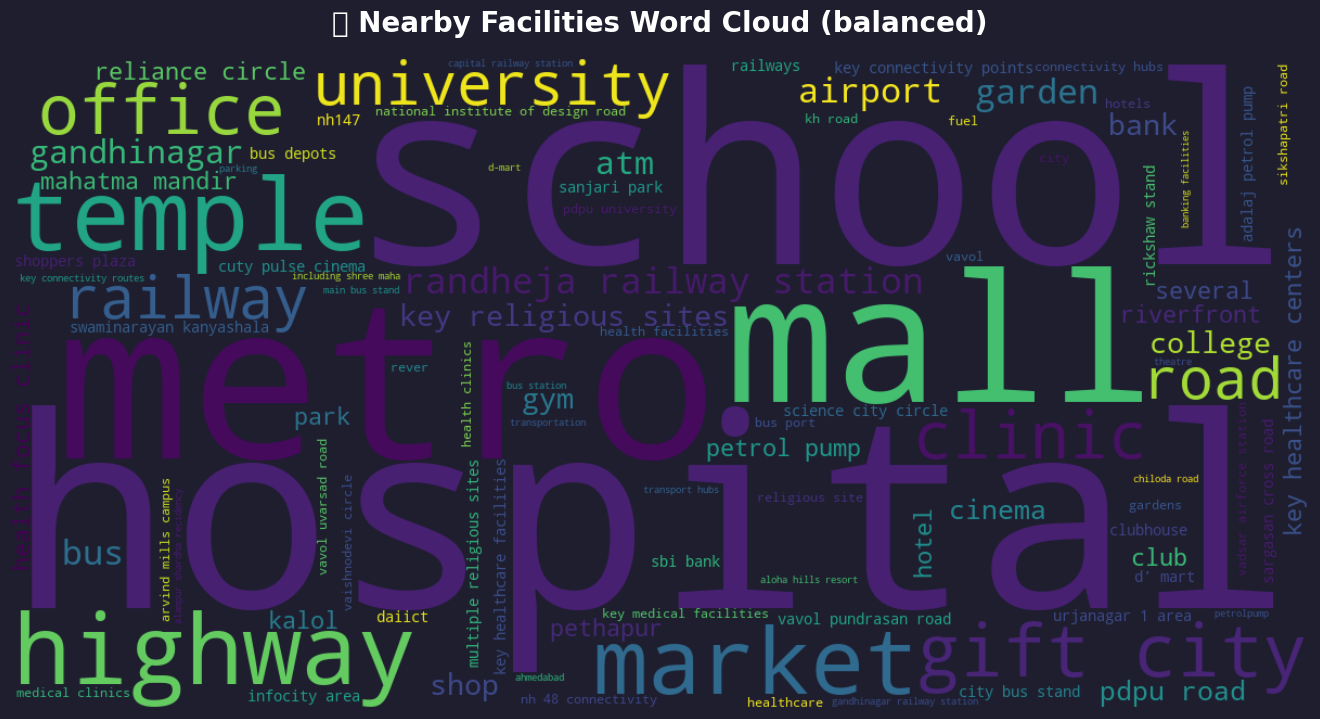

Saved as 'nearby_facilities_wordcloud_balanced_viridis.png'


In [ ]:

# Your nearby facility frequencies (copied from your output)
nearby_freq = {
    'hospital': 228, 'school': 190, 'metro': 115, 'mall': 93, 'temple': 93,
    'highway': 89, 'market': 51, 'gift city': 29, 'office': 20, 'clinic': 15,
    'university': 12, 'railway': 11, 'road': 10, 'randheja railway station': 6,
    'airport': 5, 'garden': 5, 'bus': 5, 'gandhinagar': 4, 'atm': 4,
    'key religious sites': 4, 'shop': 4, 'bank': 4, 'gym': 4, 'college': 4,
    'pdpu road': 3, 'cinema': 3, 'reliance circle': 2, 'kalol': 2, 'several': 2,
    'hotel': 2, 'pethapur': 2, 'club': 2, 'park': 2, 'key healthcare centers': 2,
    'mahatma mandir': 2, 'petrol pump': 2, 'riverfront': 2, 'health focus clinic': 2,
    'key connectivity points': 1, 'cuty pulse cinema': 1, 'swaminarayan kanyashala': 1,
    'clubhouse': 1, 'sanjari park': 1, 'railways': 1, 'bus depots': 1,
    'key healthcare facilities': 1, 'shoppers plaza': 1, 'nh147': 1,
    'multiple religious sites': 1, 'adalaj petrol pump': 1, 'daiict': 1,
    'rickshaw stand': 1, 'sbi bank': 1, 'city bus stand': 1, 'science city circle': 1,
    'vavol pundrasan road': 1, 'urjanagar 1 area': 1, 'sargasan cross road': 1,
    "d' mart": 1, 'infocity area': 1, 'national institute of design road': 1,
    'kh road': 1, 'rever': 1, 'healthcare': 1, 'key medical facilities': 1,
    'connectivity hubs': 1, 'religious site': 1, 'bus port': 1, 'health clinics': 1,
    'city': 1, 'sikshapatri road': 1, 'vaishnodevi circle': 1, 'nh 48 connectivity': 1,
    'hotels': 1, 'gardens': 1, 'health facilities': 1, 'medical clinics': 1,
    'vavol': 1, 'vavol uvarsad road': 1, 'vadsar airforce station': 1,
    'arvind mills campus': 1, 'fuel': 1, 'pdpu university': 1,
    'gandhinagar railway station': 1, 'petrolpump': 1, 'parking': 1,
    'transport hubs': 1, 'theatre': 1, 'bus station': 1,
    'alampur shardha recidency': 1, 'chiloda road': 1, 'main bus stand': 1,
    'including shree maha': 1, 'transportation': 1, 'aloha hills resort': 1,
    'ahmedabad': 1, 'key connectivity routes': 1, 'banking facilities': 1,
    'd-mart': 1, 'capital railway station': 1
}

# Apply log transformation to balance high-frequency words
log_nearby_freq = {word: np.log1p(cnt) for word, cnt in nearby_freq.items()}

# Same background and colormap as amenities
bg_color = '#1e1e2f'
colormap = 'viridis'   # consistent with amenities

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color=bg_color,
    colormap=colormap,
    max_words=120,
    relative_scaling=0.5,
    contour_width=1,
    contour_color='white',
    random_state=42
).generate_from_frequencies(log_nearby_freq)

# Display with matching background and border
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')

# Add a thin white border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('white')
    spine.set_linewidth(0.5)

plt.title('📍 Nearby Facilities Word Cloud (balanced)', fontsize=20, fontweight='bold',
          color='white', pad=20, backgroundcolor=bg_color)
plt.tight_layout(pad=0)
plt.show()

# Save
wordcloud.to_file('nearby_facilities_wordcloud_balanced_viridis.png')
print("Saved as 'nearby_facilities_wordcloud_balanced_viridis.png'")

In [ ]:
! pip install LabelEncoder

ERROR: Could not find a version that satisfies the requirement LabelEncoder (from versions: none)
ERROR: No matching distribution found for LabelEncoder


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Create a copy for modeling
model_df = df[['Price_inr', 'Area', 'Bedrooms', 'Furnishing_Status']].copy()

# Drop any rows with missing values
model_df = model_df.dropna()

# Encode Furnishing_Status (Furnished, Semi-Furnished, Unfurnished)
le = LabelEncoder()
model_df['Furnished_encoded'] = le.fit_transform(model_df['Furnishing_Status'])
# Ensure the mapping is consistent: we want 'Furnished' as 2 (or highest value)
# But it doesn't matter for prediction.

# Features and target
features = ['Area', 'Bedrooms', 'Furnished_encoded']
X = model_df[features]
y = model_df['Price_inr']

# Train a Random Forest model (quick and handles non‑linearity)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get base values for a typical property (median)
base_area = model_df['Area'].median()
base_bedrooms = model_df['Bedrooms'].median()  # e.g., 2
base_furnished = 0  # 0 = Unfurnished (lowest encoded value)
base_price = model.predict([[base_area, base_bedrooms, base_furnished]])[0]

# ============================================================
# 2. Interactive Widgets
# ============================================================

area_slider = widgets.IntSlider(
    value=int(base_area),
    min=int(model_df['Area'].min()),
    max=int(model_df['Area'].max()),
    step=50,
    description='Area (sq ft):',
    style={'description_width': 'initial'}
)

bhk_slider = widgets.IntSlider(
    value=int(base_bedrooms),
    min=int(model_df['Bedrooms'].min()),
    max=int(model_df['Bedrooms'].max()),
    step=1,
    description='BHK:',
    style={'description_width': 'initial'}
)

furnished_checkbox = widgets.Checkbox(
    value=False,
    description='Furnished?',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def update_simulator(area, bhk, furnished):
    with output:
        clear_output(wait=True)
        # Encode furnished: 0 = Unfurnished, 1 = Semi, 2 = Furnished (adjust to your encoder)
        # We'll map checkbox True -> "Furnished" and get its encoded value
        if furnished:
            furn_value = le.transform(['furnished'])[0]
        else:
            furn_value = le.transform(['unfurnished'])[0]
        
        # Predict with current settings
        predicted_price = model.predict([[area, bhk, furn_value]])[0]
        
        # Show results
        print("💰 **Current Property Price (estimate)**")
        print(f"   Area: {area} sq ft")
        print(f"   BHK: {bhk}")
        print(f"   Furnished: {'Yes' if furnished else 'No'}")
        print(f"\n   ▶ Estimated Price: ₹{predicted_price:,.0f} ({predicted_price/1e5:.1f} Lakhs)")
        
        # "What If" changes
        new_area = area + 200
        new_bhk = bhk + 1 if bhk < model_df['Bedrooms'].max() else bhk
        new_furnished = True  # always set to furnished in the "what if"
        new_furn_value = le.transform(['Furnished'])[0]
        new_price = model.predict([[new_area, new_bhk, new_furn_value]])[0]
        price_change = new_price - predicted_price
        print("\n🔄 **What If You:**")
        print(f"   + Add 200 sq ft → {new_area} sq ft")
        print(f"   + Add 1 BHK → {new_bhk} BHK")
        print(f"   + Make it Furnished → Yes")
        print(f"\n   ▶ New Estimated Price: ₹{new_price:,.0f} ({new_price/1e5:.1f} Lakhs)")
        print(f"   ▶ Price Change: + ₹{price_change:,.0f} ({price_change/1e5:.1f} Lakhs)")

# Link widgets
widgets.interactive(update_simulator, area=area_slider, bhk=bhk_slider, furnished=furnished_checkbox)

# Display
display(area_slider, bhk_slider, furnished_checkbox, output)

c:\Users\MEGH BAVARVA\Desktop\Data Scientist\Project\Real_Estate\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


IntSlider(value=1448, description='Area (sq ft):', max=9000, min=210, step=50, style=SliderStyle(description_w…

IntSlider(value=2, description='BHK:', max=6, min=1, style=SliderStyle(description_width='initial'))

Checkbox(value=False, description='Furnished?', style=CheckboxStyle(description_width='initial'))

Output()

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ============================================================
# 1. Select features for clustering (numeric + encoded categorical)
# ============================================================
feature_cols = [
    'Price_inr', 'Area', 'Bedrooms', 'Price_per_SqFt',
    'Bathrooms', 'Balconies', 'Current_Floor', 'Total_Floors'
]

# Add one‑hot encoded categorical variables
categorical_cols = ['Furnishing_Status', 'Facing', 'Property_Age']
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

# Combine numeric and encoded categorical
X = pd.concat([df[feature_cols], df_encoded], axis=1)

# Drop any rows with missing values (should not exist)
X = X.dropna()

# Keep track of index alignment
original_index = X.index

# ============================================================
# 2. Scale the features
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 3. Train K‑Means clustering (choose k, e.g., 10 or use elbow)
# ============================================================
k = 10   # you can adjust; try 8–15 for 1300 rows
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df.loc[original_index, 'cluster'] = cluster_labels

# ============================================================
# 4. Train a NearestNeighbors model inside each cluster
#    for fast “similar property” retrieval
# ============================================================
neighbors_model = NearestNeighbors(n_neighbors=6, metric='euclidean')
# We need one model per cluster (or store the scaled data per cluster)
neighbors_by_cluster = {}
for c in range(k):
    mask = df['cluster'] == c
    X_cluster = X_scaled[mask]
    if len(X_cluster) >= 6:
        nn = NearestNeighbors(n_neighbors=min(6, len(X_cluster)), metric='euclidean')
        nn.fit(X_cluster)
        neighbors_by_cluster[c] = (nn, X_cluster, df[mask].index)

# ============================================================
# 5. Function to find similar properties for a given condition
# ============================================================
def find_similar_properties(area_name, bedrooms, n=5):
    """
    Find properties matching `area_name` (Mapped_Area) and `bedrooms`.
    Returns the 5 most similar properties (excluding the query property itself),
    along with average price and average area.
    """
    # Filter candidates that match the description
    candidates = df[(df['Mapped_Area'] == area_name) & (df['Bedrooms'] == bedrooms)]
    if len(candidates) == 0:
        return f"No property found with {bedrooms} BHK in {area_name}."
    
    # Pick the first property as the “seed” (you could also take the median)
    seed_idx = candidates.index[0]
    seed_cluster = df.loc[seed_idx, 'cluster']
    
    if seed_cluster not in neighbors_by_cluster:
        return f"Cluster {seed_cluster} has insufficient properties."
    
    nn, X_cluster, cluster_indices = neighbors_by_cluster[seed_cluster]
    
    # Get scaled features of the seed property
    seed_scaled = X_scaled[original_index.get_loc(seed_idx)].reshape(1, -1)
    
    # Find nearest neighbours (including itself)
    distances, indices = nn.kneighbors(seed_scaled, n_neighbors=n+1)
    # Indices are relative to X_cluster, map back to original index
    similar_indices = cluster_indices[indices[0]][1:]   # skip the first one (itself)
    similar_props = df.loc[similar_indices[:n]]
    
    # Compute average price and area
    avg_price = similar_props['Price_inr'].mean()
    avg_area = similar_props['Area'].mean()
    
    # Return results
    print(f"\n🔍 Similar properties to: {bedrooms} BHK in {area_name}")
    print(f"   (Using seed property ID {seed_idx})\n")
    print("📊 **5 Similar Properties**")
    for idx, row in similar_props.iterrows():
        print(f"   - {int(row['Bedrooms'])} BHK, {row['Mapped_Area']}, "
              f"₹{row['Price_inr']:,.0f} ({row['Area']:.0f} sq ft)")
    print(f"\n📈 **Average of these 5:**")
    print(f"   💰 Avg Price : ₹{avg_price:,.0f} ({avg_price/1e5:.1f} Lakhs)")
    print(f"   📐 Avg Area  : {avg_area:.0f} sq ft")
    
    return similar_props, avg_price, avg_area

# ============================================================
# 6. Example usage
# ============================================================
# User clicks "3 BHK Gift City"
find_similar_properties(area_name='Gift City', bedrooms=3, n=5)


🔍 Similar properties to: 3 BHK in Gift City
   (Using seed property ID 19)

📊 **5 Similar Properties**
   - 3 BHK, Sargasan, ₹9,500,000 (2295 sq ft)
   - 3 BHK, Sargasan, ₹12,000,000 (2142 sq ft)
   - 3 BHK, Sargasan, ₹7,175,000 (1845 sq ft)
   - 3 BHK, Sector 22, ₹7,000,000 (1200 sq ft)
   - 3 BHK, Koba, ₹9,500,000 (2016 sq ft)

📈 **Average of these 5:**
   💰 Avg Price : ₹9,035,000 (90.3 Lakhs)
   📐 Avg Area  : 1900 sq ft


(       Price    Area  Bathrooms  Balconies  Current_Floor  Total_Floors  \
 1282   95.00  2295.0        2.0        1.0            4.0           8.0   
 618   120.00  2142.0        2.0        1.0            4.0           8.0   
 1023   71.75  1845.0        2.0        1.0            5.0          13.0   
 1151   70.00  1200.0        2.0        1.0            3.0           7.0   
 11     95.00  2016.0        3.0        1.0            4.0           8.0   
 
      Furnishing_Status Mapped_Area   Facing Property_Age  Bedrooms  \
 1282           Unknown    Sargasan  Unknown          New         3   
 618            Unknown    Sargasan  Unknown          New         3   
 1023           Unknown    Sargasan  Unknown          New         3   
 1151           Unknown   Sector 22  Unknown          New         3   
 11             Unknown        Koba  Unknown          New         3   
 
            Area_Type     Property_Status  Latitude  Longitude   Price_inr  \
 1282          Carpet  Under_Constru


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_27132\378637838.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


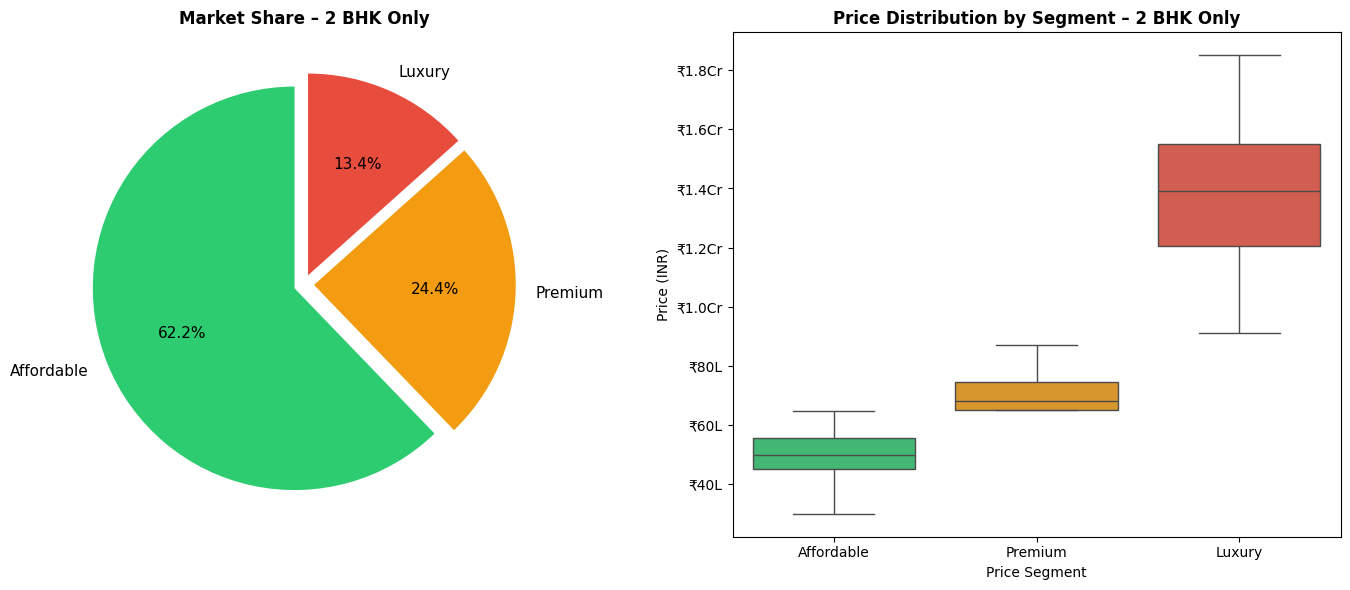


1 - All BHKs (Affordable, Premium, Luxury mixed)
2 - Only 2 BHK
3 - Only 3 BHK
4 - Only 4 BHK
0 - Exit


In [45]:
df['Bedrooms'] = df['Bedrooms'].astype(int)

# --- Segmentation function (using your price brackets) ---
def get_segment(row):
    bhk = row['Bedrooms']
    price = row['Price_inr']
    if bhk == 2:
        if price < 65e5:      return 'Affordable'
        elif price <= 90e5:   return 'Premium'
        else:                 return 'Luxury'
    elif bhk == 3:
        if price < 80e5:      return 'Affordable'
        elif price <= 120e5:  return 'Premium'
        else:                 return 'Luxury'
    elif bhk == 4:
        if price < 130e5:     return 'Affordable'
        elif price <= 180e5:  return 'Premium'
        else:                 return 'Luxury'
    else:
        return None

df['Segment'] = df.apply(get_segment, axis=1)
df_filtered = df[df['Bedrooms'].isin([2,3,4])].dropna(subset=['Segment'])

segment_order = ['Affordable', 'Premium', 'Luxury']
colors = {'Affordable': '#2ecc71', 'Premium': '#f39c12', 'Luxury': '#e74c3c'}

def plot_pie_and_box(bhk=None):
    """
    bhk = None -> all BHKs together; else 2,3,4
    Shows:
        - Pie chart of segment distribution
        - Box plot of Price_inr per segment
    """
    if bhk is None:
        data = df_filtered
        title_suffix = "All BHKs Combined"
    else:
        data = df_filtered[df_filtered['Bedrooms'] == bhk]
        title_suffix = f"{bhk} BHK Only"
    
    # Counts for pie chart
    counts = data['Segment'].value_counts().reindex(segment_order).fillna(0)
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ---- Pie chart ----
    if counts.sum() > 0:
        wedges, texts, autotexts = ax1.pie(
            counts.values, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=[colors[s] for s in counts.index],
            startangle=90,
            explode=(0.05, 0.05, 0.05),
            textprops={'fontsize': 11}
        )
        ax1.set_title(f'Market Share – {title_suffix}', fontweight='bold')
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax1.set_title(f'{title_suffix} – No Properties')
    
    # ---- Box plot of Price_inr per segment ----
    if len(data) > 0:
        # Prepare data: keep only rows with valid segments in order
        plot_data = data[data['Segment'].isin(segment_order)]
        if len(plot_data) > 0:
            sns.boxplot(
                x='Segment', 
                y='Price_inr', 
                data=plot_data, 
                order=segment_order,
                palette=colors,
                ax=ax2,
                showfliers=False  # hides outliers for cleaner view (optional)
            )
            ax2.set_title(f'Price Distribution by Segment – {title_suffix}', fontweight='bold')
            ax2.set_xlabel('Price Segment')
            ax2.set_ylabel('Price (INR)')
            
            # Format y-axis labels in lakhs/crores
            def lakh_crore_formatter(x, p):
                if x >= 1e7:
                    return f'₹{x/1e7:.1f}Cr'
                else:
                    return f'₹{x/1e5:.0f}L'
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lakh_crore_formatter))
        else:
            ax2.text(0.5, 0.5, 'No valid segment data', ha='center', va='center')
    else:
        ax2.text(0.5, 0.5, 'No properties found', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# --- Menu with filter options ---
while True:
    print("\n" + "="*40)
    print("1 - All BHKs (Affordable, Premium, Luxury mixed)")
    print("2 - Only 2 BHK")
    print("3 - Only 3 BHK")
    print("4 - Only 4 BHK")
    print("0 - Exit")
    choice = input("Enter your choice: ").strip()
    if choice == '1':
        plot_pie_and_box(bhk=None)
    elif choice == '2':
        plot_pie_and_box(bhk=2)
    elif choice == '3':
        plot_pie_and_box(bhk=3)
    elif choice == '4':
        plot_pie_and_box(bhk=4)
    elif choice == '0':
        break
    else:
        print("Invalid choice, try again.")

In [ ]:
# scatter plot between area and price using plotly

fig = px.scatter(
    df,
    x='Area',
    y='Price',
    color='Bedrooms',
    title='📍 Area vs Price — Colored by Bedrooms',
    labels={
        'Area': 'Area (sq ft)',
        'Price': 'Price (₹ in lakhs)'
    },
    hover_data=['Mapped_Area', 'Furnishing_Status', 'Facing', 'Property_Status'],
    opacity=0.8
)

# Remove trendline (already omitted)
# Format axes with commas, and force multiple ticks on x-axis
fig.update_layout(
    xaxis_title="Area (sq ft)",
    yaxis_title="Price (₹)",
    xaxis=dict(
        tickformat=",.0f",
        gridcolor='lightgray',
        # Force at least 6 evenly spaced ticks
        nticks=6
    ),
    yaxis=dict(
        tickprefix="₹",
        tickformat=",.0f",
        gridcolor='lightgray'
    ),
    hoverlabel=dict(bgcolor="white", font_size=12),
    legend_title_text="Bedrooms"
)

# Adjust marker size
fig.update_traces(marker=dict(size=10))

fig.show()

In [51]:
# Calculate count per locality
locality_counts = df['Mapped_Area'].value_counts().reset_index()
locality_counts.columns = ['Locality', 'Property_Count']

# Add percentage column
total_properties = len(df)
locality_counts['Percentage'] = (locality_counts['Property_Count'] / total_properties) * 100

# Select top 10
top10 = locality_counts.head(10)

# Pie chart (optional)import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assume your dataframe is named `df`
# Column 'Mapped_Area' contains locality names

# Calculate count per locality
locality_counts = df['Mapped_Area'].value_counts().reset_index()
locality_counts.columns = ['Locality', 'Property_Count']

# Add percentage column
total_properties = len(df)
locality_counts['Percentage'] = (locality_counts['Property_Count'] / total_properties) * 100

# Select top 10
top10 = locality_counts.head(10).copy()

# Calculate "Other" category
other_count = total_properties - top10['Property_Count'].sum()
other_pct = (other_count / total_properties) * 100


# ---- Interactive Pie Chart (with "Other" slice) ----
pie_labels = list(top10['Locality']) + ['Other']
pie_values = list(top10['Property_Count']) + [other_count]
pie_percentages = [f"{val/total_properties*100:.1f}%" for val in pie_values]

fig_pie = go.Figure(data=[go.Pie(
    labels=pie_labels,
    values=pie_values,
    textinfo='label+percent',
    insidetextorientation='radial',
    marker=dict(colors=px.colors.qualitative.Set3),
    hole=0.4   # Donut style (optional, set to 0 for full pie)
)])
fig_pie.update_layout(
    title='Market Share by Locality (Top 10 vs Others)',
    height=500,
    margin=dict(l=20, r=20, t=50, b=20)
)
fig_pie.show()

In [ ]:
import plotly.express as px

# Prepare counts
status_counts = df['Property_Status'].value_counts().reset_index()
status_counts.columns = ['Property_Status', 'Count']

# Add percentage
total = status_counts['Count'].sum()
status_counts['Percentage'] = (status_counts['Count'] / total * 100).round(1)

# Create bar chart
fig = px.bar(
    status_counts,
    x='Property_Status',
    y='Count',
    text='Count',
    color='Property_Status',
    color_discrete_map={'Ready to move': '#2ecc71', 'Under construction': '#e74c3c'},
    title='Property Status Distribution',
    labels={'Count': 'Number of Properties', 'Property_Status': ''}
)

# Customise bar appearance
fig.update_traces(
    texttemplate='%{text}<br>(%{customdata:.1f}%)',
    textposition='outside',
    marker_line_width=1,
    marker_line_color='white',
    hovertemplate='<b>%{x}</b><br>Count: %{y}<br>Percentage: %{customdata:.1f}%<extra></extra>',
    customdata=status_counts['Percentage']
)

# Layout refinements
fig.update_layout(
    height=500,
    showlegend=False,
    xaxis=dict(tickangle=0),
    yaxis=dict(gridcolor='lightgray', gridwidth=0.5),
    plot_bgcolor='white',
    title_font=dict(size=20, family='Arial', color='#2c3e50')
)

fig.show()

In [53]:
# Percentage of 'Ready_to_Move' in Property_Status column
ready_percentage = (df['Property_Status'] == 'Ready_to_Move').mean() * 100
print(f"Percentage of Ready_to_Move: {ready_percentage:.2f}%")

print("Median Price:", df['Price'].median())
print("Median Price/sqft:", ((df['Price']*100000)/df['Area']).median())

Percentage of Ready_to_Move: 81.31%
Median Price: 75.0
Median Price/sqft: 4739.023669731546


In [54]:
min_price = df['Price'].min()           # ~51.99 Lakhs
median_price = df['Price'].median()     # ~97 Lakhs
max_price = df['Price'].max()           # ~168 Lakhs

fig = go.Figure()

# Full range band (light gray)
fig.add_trace(go.Bar(
    y=['Price Spectrum'],
    x=[max_price - min_price],
    base=min_price,
    orientation='h',
    marker=dict(color='lightgray', line=dict(width=0)),
    showlegend=False,
    hoverinfo='none'
))

# Three anchor points: Entry, Median, Top
fig.add_trace(go.Scatter(
    x=[min_price, median_price, max_price],
    y=['Price Spectrum', 'Price Spectrum', 'Price Spectrum'],
    mode='markers+text',
    marker=dict(size=14, color=['#2ecc71', '#f39c12', '#e74c3c'], symbol='circle'),
    text=[
        f'Entry<br>₹{min_price:.0f}L',
        f'Median<br>₹{median_price:.0f}L',
        f'Top<br>₹{max_price/100:.2f}Cr'
    ],
    textposition='top center',
    textfont=dict(size=11, color='black'),
    showlegend=False,
    hoverinfo='text',
    hovertext=[
        f'Budget entry point: ₹{min_price} Lakhs',
        f'Mid‑market: ₹{median_price} Lakhs',
        f'Top end: ₹{max_price/100:.2f} Crore'
    ]
))

# Layout
fig.update_layout(
    title=dict(
        text='Price Range Spectrum — “Where does my budget land?”',
        font=dict(size=16),
        x=0.5
    ),
    xaxis_title='Price (₹ Lakhs)',
    yaxis=dict(showticklabels=False, title=''),
    height=280,
    margin=dict(l=50, r=50, t=80, b=40),
    plot_bgcolor='white',
    hoverlabel=dict(bgcolor='white', font_size=12)
)

# Optional: Add a vertical "your budget" line if you have user input
# user_budget = 75  # in Lakhs (example)
# fig.add_vline(x=user_budget, line_dash='dash', line_color='blue', annotation_text='Your Budget')

fig.show()

In [55]:
# Define ordered age categories
age_order = ['New', '1-5 years', '5-10 years', '10-20 years']

# Filter valid ages
df_age = df[df['Property_Age'].isin(age_order)].copy()

# Convert Price (Lakhs) to Crores
df_age['Price_Cr'] = df_age['Price'] / 100

# Group by Property_Age
summary_age = df_age.groupby('Property_Age', as_index=False).agg(
    avg_price_cr=('Price_Cr', 'mean'),
    count=('Price_Cr', 'count')
)

# Convert to categorical for correct ordering
summary_age['Property_Age'] = pd.Categorical(summary_age['Property_Age'], categories=age_order, ordered=True)
summary_age = summary_age.sort_values('Property_Age')

# Calculate premium vs New (baseline)
new_price = summary_age.loc[summary_age['Property_Age'] == 'New', 'avg_price_cr'].values[0]
summary_age['premium_pct'] = ((summary_age['avg_price_cr'] - new_price) / new_price * 100).round(0)
summary_age['premium_pct'] = summary_age['premium_pct'].fillna(0).astype(int)

# Bar chart
fig = px.bar(
    summary_age,
    x='Property_Age',
    y='avg_price_cr',
    text='avg_price_cr',
    color='Property_Age',
    color_discrete_map={
        'New': '#2ecc71',
        '1-5 years': '#f39c12',
        '5-10 years': '#e67e22',
        '10-20 years': '#e74c3c'
    },
    title='🏚️ Average Price by Property Age — "Does newer cost more?"',
    labels={'avg_price_cr': 'Average Price (₹ Crore)', 'Property_Age': ''}
)

# Format bar labels
fig.update_traces(
    texttemplate='₹%{text:.2f}Cr',
    textposition='outside',
    marker_line_width=0
)

# Add premium annotations above bars
for i, row in summary_age.iterrows():
    if row['Property_Age'] == 'New':
        annotation_text = 'baseline'
    else:
        annotation_text = f"{row['premium_pct']:+.0f}% vs New"
    fig.add_annotation(
        x=row['Property_Age'],
        y=row['avg_price_cr'] + 0.05,
        text=annotation_text,
        showarrow=False,
        font=dict(size=10, color='#2c3e50'),
        bgcolor='white',
        bordercolor='#ddd',
        borderwidth=1
    )

# Add sample size below bars
for i, row in summary_age.iterrows():
    fig.add_annotation(
        x=row['Property_Age'],
        y=row['avg_price_cr'] - 0.08,
        text=f"n={row['count']}",
        showarrow=False,
        font=dict(size=9, color='gray')
    )

# Layout
fig.update_layout(
    yaxis=dict(tickprefix='₹', tickformat='.2f', title='Average Price (₹ Crore)'),
    height=500,
    uniformtext_minsize=12,
    showlegend=False
)

fig.show()

# Print a quick summary
print("Average price by property age (₹ Crore):")
for _, row in summary_age.iterrows():
    print(f"{row['Property_Age']:12s}: ₹{row['avg_price_cr']:.2f}Cr  (n={row['count']})")

Average price by property age (₹ Crore):
New         : ₹1.01Cr  (n=617)
1-5 years   : ₹0.86Cr  (n=165)
5-10 years  : ₹0.62Cr  (n=119)
10-20 years : ₹0.60Cr  (n=59)


In [59]:
df['Price_per_SqFt'].mean()

np.float64(5917.399598485435)

In [56]:
# Prepare data
df_furnish = df[df['Furnishing_Status'].isin(['furnished', 'semi-furnished', 'unfurnished'])].copy()
df_furnish['Price_Cr'] = df_furnish['Price'] / 100  # Lakhs → Crores

# Aggregate
summary = df_furnish.groupby('Furnishing_Status', as_index=False).agg(
    avg_price_cr=('Price_Cr', 'mean'),
    count=('Price_Cr', 'count')
)

# Calculate premium vs unfurnished
unfurnished_price = summary.loc[summary['Furnishing_Status'] == 'unfurnished', 'avg_price_cr'].values[0]
summary['premium_pct'] = ((summary['avg_price_cr'] - unfurnished_price) / unfurnished_price * 100).round(0)
summary['premium_pct'] = summary['premium_pct'].fillna(0).astype(int)

# Rename for display
status_labels = {'furnished': 'Furnished', 'semi-furnished': 'Semi‑furnished', 'unfurnished': 'Unfurnished'}
summary['Status'] = summary['Furnishing_Status'].map(status_labels)

# Bar chart
fig = px.bar(
    summary,
    x='Status',
    y='avg_price_cr',
    text='avg_price_cr',
    color='Status',
    color_discrete_map={
        'Furnished': '#e74c3c',
        'Semi‑furnished': '#f39c12',
        'Unfurnished': '#95a5a6'
    },
    title='🛋️ Furnishing Status Price Delta — "Is furnished worth the premium?"',
    labels={'avg_price_cr': 'Average Price (₹ Crore)', 'Status': ''}
)

# Format text on bars
fig.update_traces(
    texttemplate='₹%{text:.2f}Cr',
    textposition='outside',
    marker_line_width=0
)

# Add premium annotations above each bar
for i, row in summary.iterrows():
    if row['Furnishing_Status'] == 'unfurnished':
        annotation_text = f"baseline"
    else:
        annotation_text = f"+{row['premium_pct']}% vs unfurnished"
    fig.add_annotation(
        x=row['Status'],
        y=row['avg_price_cr'] + 0.05,
        text=annotation_text,
        showarrow=False,
        font=dict(size=10, color='#2c3e50'),
        bgcolor='white',
        bordercolor='#ddd',
        borderwidth=1
    )

# Add sample size as secondary text
for i, row in summary.iterrows():
    fig.add_annotation(
        x=row['Status'],
        y=row['avg_price_cr'] - 0.08,
        text=f"n={row['count']}",
        showarrow=False,
        font=dict(size=9, color='gray')
    )

# Layout
fig.update_layout(
    yaxis=dict(tickprefix='₹', tickformat='.2f', title='Average Price (₹ Crore)'),
    height=500,
    uniformtext_minsize=12,
    showlegend=False
)

fig.show()

In [ ]:
# ----- Prepare data -----
df_furnish = df[df['Furnishing_Status'].isin(['furnished', 'semi-furnished', 'unfurnished'])].copy()

# Ensure column exists (if not, create or rename)
df_furnish['Price_per_SqFt'] = df_furnish['Price_per_SqFt']  # adjust if column name differs

# ----- Aggregate using MEDIAN -----
summary = df_furnish.groupby('Furnishing_Status', as_index=False).agg(
    avg_price_psf=('Price_per_SqFt', 'median'),   # changed from mean to median
    count=('Price_per_SqFt', 'count')
)

# ----- Calculate premium vs unfurnished (based on median) -----
unfurnished_price_psf = summary.loc[summary['Furnishing_Status'] == 'unfurnished', 'avg_price_psf'].values[0]
summary['premium_pct'] = ((summary['avg_price_psf'] - unfurnished_price_psf) / unfurnished_price_psf * 100).round(0)
summary['premium_pct'] = summary['premium_pct'].fillna(0).astype(int)

# ----- Rename statuses for display -----
status_labels = {'furnished': 'Furnished', 'semi-furnished': 'Semi‑furnished', 'unfurnished': 'Unfurnished'}
summary['Status'] = summary['Furnishing_Status'].map(status_labels)

# ----- Bar chart with Plotly Express -----
import plotly.express as px

fig = px.bar(
    summary,
    x='Status',
    y='avg_price_psf',
    text='avg_price_psf',
    color='Status',
    color_discrete_map={
        'Furnished': '#e74c3c',
        'Semi‑furnished': '#f39c12',
        'Unfurnished': '#95a5a6'
    },
    title='🛋️ Furnishing Status Price per Sq Ft (Median) — "Is furnished worth the premium?"',
    labels={'avg_price_psf': 'Median Price per Sq Ft (₹)', 'Status': ''}
)

# ----- Format text on bars -----
fig.update_traces(
    texttemplate='₹%{text:,.0f}',
    textposition='outside',
    marker_line_width=0
)

# ----- Add premium annotations above each bar -----
for i, row in summary.iterrows():
    if row['Furnishing_Status'] == 'unfurnished':
        annotation_text = "baseline"
    else:
        annotation_text = f"+{row['premium_pct']}% vs unfurnished"
    fig.add_annotation(
        x=row['Status'],
        y=row['avg_price_psf'] + (row['avg_price_psf'] * 0.05),
        text=annotation_text,
        showarrow=False,
        font=dict(size=10, color='#2c3e50'),
        bgcolor='white',
        bordercolor='#ddd',
        borderwidth=1
    )

# ----- Add sample size (n=...) below each bar -----
for i, row in summary.iterrows():
    fig.add_annotation(
        x=row['Status'],
        y=row['avg_price_psf'] - (row['avg_price_psf'] * 0.08),
        text=f"n={row['count']}",
        showarrow=False,
        font=dict(size=9, color='gray')
    )

# ----- Layout adjustments -----
fig.update_layout(
    yaxis=dict(
        tickprefix='₹',
        tickformat=',.0f',
        title='Median Price per Sq Ft (₹)'
    ),
    height=500,
    uniformtext_minsize=12,
    showlegend=False
)

fig.show()

In [ ]:
df.groupby('Furnishing_Status')['Price_per_SqFt'].median()

Furnishing_Status
Unknown           100.476948
furnished          84.860521
semi-furnished     73.203390
unfurnished        87.027129
Name: Price, dtype: float64

In [64]:
# Define ordered age categories
age_order = ['New', '1-5 years', '5-10 years', '10-20 years']

# Prepare base data
df_age = df[df['Property_Age'].isin(age_order)].copy()
df_age['Price_Cr'] = df_age['Price'] / 100

# Create BHK category: 4+ for Bedrooms >= 4
df_age['BHK_category'] = df_age['Bedrooms'].apply(
    lambda x: f"{int(x)} BHK" if x < 4 else "4+ BHK"
)

def plot_age_by_bhk(bhk_filter='All'):
    # Filter by BHK if not 'All'
    if bhk_filter != 'All':
        filtered_df = df_age[df_age['BHK_category'] == bhk_filter]
    else:
        filtered_df = df_age.copy()
    
    # Group by Property_Age
    summary = filtered_df.groupby('Property_Age', as_index=False).agg(
        avg_price_cr=('Price_Cr', 'mean'),
        count=('Price_Cr', 'count')
    )
    
    # Categorical ordering
    summary['Property_Age'] = pd.Categorical(summary['Property_Age'], categories=age_order, ordered=True)
    summary = summary.sort_values('Property_Age')
    
    # Create bar chart with CONTINUOUS COLOR based on avg_price_cr
    fig = px.bar(
        summary,
        x='Property_Age',
        y='avg_price_cr',
        color='avg_price_cr',           # continuous color by price
        color_continuous_scale='YlOrRd', # light to dark blue (can change to Greens, Oranges, etc.)
        title=f'🏚️ Average Price by Property Age — {bhk_filter}',
        labels={'avg_price_cr': 'Average Price (₹ Crore)', 'Property_Age': ''}
    )
    
    # Remove text, keep clean bars
    fig.update_traces(
        text=None,
        textposition=None,
        marker_line_width=0
    )
    
    # Layout adjustments
    fig.update_layout(
        yaxis=dict(tickprefix='₹', tickformat='.2f', title='Average Price (₹ Crore)'),
        height=500,
        showlegend=False,
        uniformtext_minsize=10,
        coloraxis_colorbar=dict(title="Price (₹ Cr)")  # optional color bar
    )
    fig.show()

# Create dropdown widget
bhk_options = ['All'] + sorted(df_age['BHK_category'].unique())
dropdown = widgets.Dropdown(
    options=bhk_options,
    value='All',
    description='BHK:',
    style={'description_width': 'initial'}
)

# Interactive output
widgets.interactive(plot_age_by_bhk, bhk_filter=dropdown)

interactive(children=(Dropdown(description='BHK:', options=('All', '1 BHK', '2 BHK', '3 BHK', '4+ BHK'), style…

In [65]:
# More granular bins (adjust min/max based on your data)
min_price = df['Price'].min()
max_price = df['Price'].max()

# Define 7 bins: 40-60, 60-80, 80-100, 100-120, 120-140, 140-160, 160+
bins = [40, 70, 100, 140, 200, max_price + 10]
labels = ['₹40–70L', '₹70L–1Cr', '₹1–1.–1.4Cr', '₹1.4–2Cr', '₹2Cr+']

# Alternatively, use automatic binning with numpy (e.g., 8 equal-width bins)
# bins = np.linspace(min_price, max_price, 9)  # 8 bins
# labels = [f'₹{bins[i]:.0f}–{bins[i+1]:.0f}L' for i in range(len(bins)-1)]

# Create a copy and bin the prices
df_price_bins = df.copy()
df_price_bins['Price_Bracket'] = pd.cut(df_price_bins['Price'], bins=bins, labels=labels, right=False)

# Count listings per bracket
bracket_counts = df_price_bins['Price_Bracket'].value_counts().reindex(labels, fill_value=0)

# Bar chart
fig = px.bar(
    x=bracket_counts.index,
    y=bracket_counts.values,
    text=bracket_counts.values,
    color=bracket_counts.values,
    color_continuous_scale='magma',
    title='Price Distribution',
    labels={'x': 'Price Bracket (₹)', 'y': 'Number of Listings'}
)

# Format bars
fig.update_traces(
    texttemplate='%{text} listings',
    textposition='outside',
    marker_line_width=0
)

# Layout
fig.update_layout(
    xaxis_title='Price Bracket',
    yaxis_title='Number of Properties',
    coloraxis_showscale=False,
    height=450
)

fig.show()

In [ ]:
import joblib

In [ ]:
# Load your pipeline
pipeline = joblib.load("backend\models\model_full_data.pkl")
print("✅ Pipeline loaded.")

# Feature columns (same as training)
feature_columns = [
    'Area', 'Bathrooms', 'Balconies', 'Current_Floor', 'Total_Floors', 'Bedrooms',
    'Mapped_Area', 'Property_Age', 'Furnishing_Status', 'Area_Type', 'Property_Status', 'Facing'
]

X = df[feature_columns].copy()

# Predict (log scale) and back-transform to Lakhs
pred_log = pipeline.predict(X)
pred_lakh = np.expm1(pred_log)   # if target was log1p; else use raw predictions
actual_lakh = df['Price'].values

# Deviation % (positive = actual > predicted → "Above Estimated")
deviation_pct = (actual_lakh - pred_lakh) / pred_lakh * 100

# Classify with recommended wording
def classify(dev):
    if dev < -10:
        return "Below Estimated Value"
    elif dev > 10:
        return "Above Estimated Value"
    else:
        return "Near Estimated Value"

df_eval = df.copy()
df_eval['Predicted_Lakh'] = pred_lakh
df_eval['Deviation_%'] = deviation_pct
df_eval['Valuation'] = df_eval['Deviation_%'].apply(classify)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\MEGH BAVARVA\AppData\Local\Temp\ipykernel_14512\4261649542.py:2: SyntaxWarning: invalid escape sequence '\m'
  pipeline = joblib.load("backend\models\model_full_data.pkl")


✅ Pipeline loaded.


In [ ]:
# Count distribution
dist = df_eval['Valuation'].value_counts()
dist = dist.reindex(['Below Estimated Value', 'Near Estimated Value', 'Above Estimated Value'])

# High-contrast colors: deep teal (below), amber (near), rich red (above)
high_contrast_colors = ['#1e88e5', '#ffb300', '#e53935']  # or use: '#00bcd4', '#ffc107', '#d32f2f'

# Donut chart with larger dimensions
fig_dist = go.Figure(data=[go.Pie(
    labels=dist.index,
    values=dist.values,
    hole=0.45,                  # slightly larger hole for donut effect
    marker=dict(colors=high_contrast_colors, line=dict(color='white', width=2)),  # white separation lines
    textinfo='label+percent',
    textposition='auto',
    textfont=dict(size=13, color='black'),
    pull=[0.05, 0, 0.05],       # slightly separate "Below" and "Above" for emphasis
    sort=False
)])

fig_dist.update_layout(
    title=dict(
        text='Market Pricing Distribution',
        font=dict(size=16, weight='bold'),
        x=0.5
    ),
    height=500,                 # increased from 450
    width=700,                  # explicit width for larger canvas
    margin=dict(l=40, r=40, t=80, b=40),
    annotations=[
        dict(
            text=f'Total<br>{len(df_eval)}', 
            x=0.5, y=0.5, 
            font=dict(size=16, weight='bold', color='#2c3e50'), 
            showarrow=False
        )
    ]
)

fig_dist.show()


In [ ]:
# Helper to format currency
def cr_format(lakh):
    return f"₹{lakh/100:.2f}Cr" if lakh >= 100 else f"₹{lakh:.0f}L"

# Sample 3 properties from each category (or fewer if not enough)
samples = {}
for cat in ['Below Estimated Value', 'Near Estimated Value', 'Above Estimated Value']:
    cat_df = df_eval[df_eval['Valuation'] == cat]
    samples[cat] = cat_df.head(3)   # or .sample(3) if you want random

# Create a simple Plotly table for samples
rows = []
for cat, df_cat in samples.items():
    for _, row in df_cat.iterrows():
        rows.append([
            cat,
            row['Mapped_Area'],
            f"{int(row['Bedrooms'])} BHK",
            f"{row['Area']:.0f} sqft",
            cr_format(row['Price']),
            cr_format(row['Predicted_Lakh']),
            f"{row['Deviation_%']:+.0f}%"
        ])

# Build the table
fig_samples = go.Figure(data=[go.Table(
    header=dict(values=['<b>Valuation</b>', '<b>Locality</b>', '<b>BHK</b>', '<b>Area</b>',
                        '<b>Listed Price</b>', '<b>Model Estimate</b>', '<b>Difference</b>'],
                fill_color='#2c3e50', font=dict(color='white', size=11), align='left'),
    cells=dict(values=list(zip(*rows)), fill_color='lightgray', align='left', height=30)
)])
fig_samples.update_layout(title='🔍 Sample Market Opportunities — "Where does value lie?"', height=500)
fig_samples.show()

In [ ]:
# Select one example from each category
example_below = df_eval[df_eval['Valuation'] == 'Below Estimated Value'].iloc[1]
example_near = df_eval[df_eval['Valuation'] == 'Near Estimated Value'].iloc[2]
example_above = df_eval[df_eval['Valuation'] == 'Above Estimated Value'].iloc[0]

# Helper to format price (convert Lakhs to Crore if >= 100)
def fmt(lakh):
    return f"₹{lakh/100:.2f}Cr" if lakh >= 100 else f"₹{lakh:.0f}L"

# Print the three examples
print("🏷️ **Sample Market Opportunities**\n")

print(f"🟢 **Below Estimated Value**")
print(f"   {int(example_below['Bedrooms'])} BHK · {example_below['Mapped_Area']}")
print(f"   {example_below['Area']:.0f} sqft")
print(f"   Listed: {fmt(example_below['Price'])}")
print(f"   Estimated: {fmt(example_below['Predicted_Lakh'])}")
print(f"   ↓ {abs(example_below['Deviation_%']):.0f}% below estimated value\n")

print(f"🔴 **Above Estimated Value**")
print(f"   {int(example_above['Bedrooms'])} BHK · {example_above['Mapped_Area']}")
print(f"   {example_above['Area']:.0f} sqft")
print(f"   Listed: {fmt(example_above['Price'])}")
print(f"   Estimated: {fmt(example_above['Predicted_Lakh'])}")
print(f"   ↑ {example_above['Deviation_%']:.0f}% above estimated value\n")

print(f"🟡 **Near Estimated Value**")
print(f"   {int(example_near['Bedrooms'])} BHK · {example_near['Mapped_Area']}")
print(f"   {example_near['Area']:.0f} sqft")
print(f"   Listed: {fmt(example_near['Price'])}")
print(f"   Estimated: {fmt(example_near['Predicted_Lakh'])}")
print(f"   ≈ Close to estimated value")

🏷️ **Sample Market Opportunities**

🟢 **Below Estimated Value**
   3 BHK · Randesan
   1170 sqft
   Listed: ₹75L
   Estimated: ₹84L
   ↓ 10% below estimated value

🔴 **Above Estimated Value**
   3 BHK · Sargasan
   2124 sqft
   Listed: ₹1.25Cr
   Estimated: ₹1.12Cr
   ↑ 12% above estimated value

🟡 **Near Estimated Value**
   3 BHK · Raysan
   1908 sqft
   Listed: ₹97L
   Estimated: ₹94L
   ≈ Close to estimated value


In [ ]:
feature_columns = [
    'Area', 'Bathrooms', 'Balconies', 'Current_Floor', 'Total_Floors', 'Bedrooms',
    'Mapped_Area', 'Property_Age', 'Furnishing_Status', 'Area_Type', 'Property_Status', 'Facing'
]

# Assuming your main DataFrame is called 'df'
X_pred = df[feature_columns].copy()

In [ ]:
# Predict in log scale
pred_log = pipeline.predict(X_pred)

# Convert back to original scale (Lakhs)
pred_lakh = np.expm1(pred_log)

In [ ]:
# Convert to Crore for display
df_pred = df.copy()
df_pred['Predicted_Price_Lakh'] = pred_lakh
df_pred['Actual_Price_Cr'] = df_pred['Price'] / 100
df_pred['Predicted_Price_Cr'] = df_pred['Predicted_Price_Lakh'] / 100

# Percentage deviation (positive = overpriced, negative = undervalued)
df_pred['Deviation_%'] = ((df_pred['Actual_Price_Cr'] - df_pred['Predicted_Price_Cr']) 
                          / df_pred['Predicted_Price_Cr']) * 100

def get_badge(dev):
    if dev > 10:
        return 'Overpriced'
    elif dev < -10:
        return 'Undervalued'
    else:
        return 'Fair'

df_pred['Valuation'] = df_pred['Deviation_%'].apply(get_badge)

In [ ]:
# Show top 30 properties with largest deviation (both over and under)
display_df = df_pred.nlargest(30, 'Deviation_%', keep='all')

# Colours for the valuation column
badge_colours = display_df['Valuation'].map({
    'Undervalued': '#d4edda',   # light green
    'Overpriced': '#f8d7da',    # light red
    'Fair': '#e2e3e5'           # light gray
})

fig = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Locality</b>', '<b>BHK</b>', '<b>Area (sqft)</b>', 
                '<b>Actual (₹Cr)</b>', '<b>Predicted (₹Cr)</b>', '<b>Valuation</b>'],
        fill_color='#2c3e50',
        font=dict(color='white', size=12),
        align='center',
        height=40
    ),
    cells=dict(
        values=[
            display_df['Mapped_Area'],
            display_df['Bedrooms'].astype(int),
            display_df['Area'].round(0),
            display_df['Actual_Price_Cr'].round(2),
            display_df['Predicted_Price_Cr'].round(2),
            display_df['Valuation']
        ],
        fill_color=[
            'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray',
            badge_colours
        ],
        font=dict(color='black', size=11),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title='🔍 Price vs Model Prediction — "Is this listing over or underpriced?"',
    height=600,
    margin=dict(l=20, r=20, t=60, b=20)
)
fig.show()

In [ ]:
undervalued = df_pred[df_pred['Valuation'] == 'Undervalued'].nlargest(3, 'Deviation_%', keep='all')
overpriced = df_pred[df_pred['Valuation'] == 'Overpriced'].nlargest(3, 'Deviation_%', keep='all')

print("🏷️ **Best Undervalued Deals** (Actual < Predicted by >10%):")
for _, row in undervalued.iterrows():
    print(f"📍 {row['Mapped_Area']} | {int(row['Bedrooms'])} BHK | ₹{row['Actual_Price_Cr']:.2f}Cr vs predicted ₹{row['Predicted_Price_Cr']:.2f}Cr | 🟢 -{abs(row['Deviation_%']):.0f}%")

print("\n⚠️ **Most Overpriced Listings** (Actual > Predicted by >10%):")
for _, row in overpriced.iterrows():
    print(f"📍 {row['Mapped_Area']} | {int(row['Bedrooms'])} BHK | ₹{row['Actual_Price_Cr']:.2f}Cr vs predicted ₹{row['Predicted_Price_Cr']:.2f}Cr | 🔴 +{row['Deviation_%']:.0f}%")

🏷️ **Best Undervalued Deals** (Actual < Predicted by >10%):
📍 Sector 6 | 2 BHK | ₹0.42Cr vs predicted ₹0.47Cr | 🟢 -10%
📍 Dahegam | 2 BHK | ₹0.37Cr vs predicted ₹0.41Cr | 🟢 -10%
📍 Gift City | 4 BHK | ₹3.26Cr vs predicted ₹3.63Cr | 🟢 -10%

⚠️ **Most Overpriced Listings** (Actual > Predicted by >10%):
📍 Kalol | 1 BHK | ₹0.55Cr vs predicted ₹0.21Cr | 🔴 +157%
📍 Raysan | 3 BHK | ₹3.00Cr vs predicted ₹1.65Cr | 🔴 +82%
📍 Sector 6 | 3 BHK | ₹3.80Cr vs predicted ₹2.09Cr | 🔴 +81%


In [ ]:
 # Prepare data: create BHK category (1,2,3,4+)
df_bhk = df.copy()
df_bhk['BHK'] = df_bhk['Bedrooms'].apply(lambda x: f"{int(x)} BHK" if x < 4 else "4+ BHK")

# Get sorted list of localities for dropdown (include 'All')
localities = sorted(df_bhk['Mapped_Area'].unique())
locality_options = ['All'] + localities

def plot_bhk_pie(selected_locality='All'):
    # Filter data
    if selected_locality != 'All':
        filtered = df_bhk[df_bhk['Mapped_Area'] == selected_locality]
    else:
        filtered = df_bhk
    
    # Count BHK distribution
    bhk_counts = filtered['BHK'].value_counts().reset_index()
    bhk_counts.columns = ['BHK', 'count']
    
    # Order BHK categories
    order = ['1 BHK', '2 BHK', '3 BHK', '4+ BHK']
    bhk_counts['BHK'] = pd.Categorical(bhk_counts['BHK'], categories=order, ordered=True)
    bhk_counts = bhk_counts.sort_values('BHK').fillna(0)
    
    # Create pie chart with a professional color sequence (continuous-like appearance)
    fig = px.pie(
        bhk_counts,
        values='count',
        names='BHK',
        title=f'🏡 BHK Distribution — {selected_locality}' if selected_locality != 'All' else '🏡 BHK Distribution — Entire Gandhinagar',
        color='BHK',
        color_discrete_sequence=px.colors.sequential.Greens_r,  # reversed Greens gradient (dark to light)
        hole=0.3
    )
    fig.update_traces(textposition='inside', textinfo='percent+label', textfont=dict(color='white', size=12))
    fig.update_layout(
        height=500,
        margin=dict(l=40, r=40, t=80, b=40),
        annotations=[dict(text=f'Total: {len(filtered)}', x=0.5, y=0.5, font_size=14, showarrow=False)]
    )
    fig.show()

# Create dropdown
dropdown = widgets.Dropdown(
    options=locality_options,
    value='All',
    description='Locality:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interactive(plot_bhk_pie, selected_locality=dropdown)

interactive(children=(Dropdown(description='Locality:', layout=Layout(width='400px'), options=('All', 'Adalaj'…

In [67]:

# Prepare data
df_bhk = df.copy()
df_bhk['BHK'] = df_bhk['Bedrooms'].apply(lambda x: f"{int(x)} BHK" if x < 4 else "4+ BHK")

# Count BHK distribution
bhk_counts = df_bhk['BHK'].value_counts().reset_index()
bhk_counts.columns = ['BHK', 'count']

# Order categories
order = ['1 BHK', '2 BHK', '3 BHK', '4+ BHK']
bhk_counts['BHK'] = pd.Categorical(bhk_counts['BHK'], categories=order, ordered=True)
bhk_counts = bhk_counts.sort_values('BHK').fillna(0)

# Create donut pie chart
fig = px.pie(
    bhk_counts,
    values='count',
    names='BHK',
    title='🏡 BHK Distribution — Entire Gandhinagar',
    color='BHK',
    color_discrete_sequence=px.colors.sequential.Blues_r,  # green gradient
    hole=0.3
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    textfont=dict(color='white', size=12)
)

fig.update_layout(
    height=500,
    margin=dict(l=40, r=40, t=80, b=40),
    annotations=[dict(text=f'Total: {len(df_bhk)}', x=0.5, y=0.5, font_size=14, showarrow=False)]
)

fig.show()

In [ ]:
# Prepare data: create BHK category (1,2,3,4+)
df_heat = df.copy()
df_heat['BHK'] = df_heat['Bedrooms'].apply(lambda x: f"{int(x)} BHK" if x < 4 else "4+ BHK")

# Calculate average price per sq.ft for each (Locality, BHK) combination
# Use median to avoid outlier distortion
pivot = df_heat.pivot_table(
    values='Price_per_SqFt',
    index='Mapped_Area',
    columns='BHK',
    aggfunc='median',   # try 'mean' if you prefer
    fill_value=0
)

# Sort localities by overall median price (optional, makes heatmap more insightful)
pivot['Overall_Median'] = pivot.median(axis=1)
pivot = pivot.sort_values('Overall_Median', ascending=False).drop('Overall_Median', axis=1)

# Reorder BHK columns logically
bhk_order = ['1 BHK', '2 BHK', '3 BHK', '4+ BHK']
pivot = pivot[[col for col in bhk_order if col in pivot.columns]]

# Create heatmap
fig = px.imshow(
    pivot,
    text_auto='.0f',               # show value as integer
    color_continuous_scale='RdYlGn',  # green = high price, red = low price
    aspect='auto',
    title='📍 Locality × BHK Heatmap — Median Price per Sq.Ft (₹)'
)

fig.update_layout(
    xaxis_title='BHK Type',
    yaxis_title='Locality',
    height=max(600, len(pivot)*25),   # dynamic height based on number of localities
    margin=dict(l=100, r=20, t=80, b=50),
    coloraxis_colorbar=dict(title='₹ / sq.ft')
)

fig.update_xaxes(side='top')   # BHK labels on top for readability
fig.update_traces(
    hovertemplate='Locality: %{y}<br>BHK: %{x}<br>Median ₹/sq.ft: %{z:,.0f}<extra></extra>'
)

fig.show()

# Optional: print insight about the most expensive combination
max_val = pivot.max().max()
max_loc = pivot.stack()[pivot.stack() == max_val].index[0]
print(f"📊 Top premium combination: {max_loc[1]} in {max_loc[0]} – ₹{max_val:,.0f}/sq.ft")

📊 Top premium combination: 3 BHK in Sector 6 – ₹25,589/sq.ft


In [ ]:
# Prepare data: create BHK category
df_count = df.copy()
df_count['BHK'] = df_count['Bedrooms'].apply(lambda x: f"{int(x)} BHK" if x < 4 else "4+ BHK")

# Create pivot table with counts
pivot_count = df_count.pivot_table(
    values='Price',  # any column works; we just need count
    index='Mapped_Area',
    columns='BHK',
    aggfunc='count',   # frequency
    fill_value=0
)

# Sort by total listings per locality (most active first)
pivot_count['Total'] = pivot_count.sum(axis=1)
pivot_count = pivot_count.sort_values('Total', ascending=False).drop('Total', axis=1)

# Keep only relevant BHK columns
bhk_order = ['1 BHK', '2 BHK', '3 BHK', '4+ BHK']
pivot_count = pivot_count[[col for col in bhk_order if col in pivot_count.columns]]

# Create heatmap
fig = px.imshow(
    pivot_count,
    text_auto=True,               # show the count number
    color_continuous_scale='Blues',
    aspect='auto',
    title='📊 Locality × BHK Heatmap — Number of Listings (Frequency)'
)

fig.update_layout(
    xaxis_title='BHK Type',
    yaxis_title='Locality',
    height=max(500, len(pivot_count)*25),
    margin=dict(l=100, r=20, t=80, b=50),
    coloraxis_colorbar=dict(title='Count of Listings')
)

fig.update_xaxes(side='top')
fig.update_traces(
    hovertemplate='Locality: %{y}<br>BHK: %{x}<br>Listings: %{z}<extra></extra>'
)

fig.show()

# Print top combination
max_loc = pivot_count.stack().idxmax()
print(f"🏘️ Most common combination: {max_loc[1]} in {max_loc[0]} – {pivot_count.loc[max_loc[0], max_loc[1]]} listings")

🏘️ Most common combination: 2 BHK in Sargasan – 188 listings


In [ ]:
import plotly.graph_objects as go

# The exact insights (unchanged)
insights = [
    "1. Gandhinagar is primarily an affordable-to-premium market.<br>"
    "<b>41% of listings fall in the affordable segment, while 37% belong to the premium category. Luxury homes account for only 22% of the market.</b>",

    "2. Gift City is the city's premium hotspot.<br>"
    "<b>Gift City records the highest average price per square foot, exceeding ₹16,000/sq.ft and standing far above other localities.</b>",

    "3. Kalol and Dahegam offer the most budget-friendly options.<br>"
    "<b>With prices ranging between ₹3,200–₹4,000 per sq.ft, these areas are ideal for buyers seeking affordability.</b>",

    "4. Housing activity is concentrated in a few key areas.<br>"
    "<b>Localities such as Sargasan, Kudasan, Gift City, Randesan, and Vavol dominate the market, offering buyers the widest range of choices.</b>",

    "5. Property prices vary significantly across Gandhinagar.<br>"
    "<b>The heat map reveals substantial differences in price per square foot, highlighting the importance of locality when making purchasing decisions.</b>",

    "6. Larger homes generally cost more, but location still matters.<br>"
    "<b>While property prices tend to increase with built-up area, homes of similar sizes can have very different prices depending on where they are located.</b>",

    "7. Family-sized homes dominate the market.<br>"
    "<b>2 BHK and 3 BHK properties make up the majority of listings, indicating strong demand from family homebuyers.</b>",

    "8. Most properties are priced close to their estimated market value.<br>"
    "<b>About 81% of listings align closely with the model's estimated value, suggesting that the Gandhinagar market is relatively efficient.</b>",

    "9. Opportunities still exist for informed buyers.<br>"
    "<b>Approximately 9% of listings appear attractively priced, while 10% are listed above estimated value, creating opportunities for negotiation and value discovery.</b>",

    "10. Budget expectations vary by home configuration.<br>"
    "<b>Buyers can typically expect:</b><br>"
    "• 2 BHK: Affordable below ₹65L, Premium between ₹65L–₹90L.<br>"
    "• 3 BHK: Affordable below ₹80L, Premium between ₹80L–₹1.2Cr.<br>"
    "• 4 BHK: Affordable below ₹1.3Cr, Premium between ₹1.3Cr–₹1.8Cr.<br>"
    "<i>These ranges provide realistic expectations for different buyer segments.</i>"
]

# Create figure
fig = go.Figure()

# Add a white card background
fig.add_shape(type="rect", xref="paper", yref="paper",
              x0=0, y0=0, x1=1, y1=1,
              fillcolor="white", line=dict(color="#2c3e50", width=2), layer="below")

# Title with final takeaway
title_text = ("<b>📌 Key Market Insights – Gandhinagar Real Estate</b><br>"
              "<i>Gandhinagar's real estate market is largely driven by location, family-oriented housing demand, "
              "and value-conscious pricing. While premium corridors such as Gift City command substantial premiums, "
              "buyers can still find attractive opportunities in emerging and affordable localities. Most listings appear fairly priced, "
              "making the market relatively transparent and efficient for informed decision-making.</i>")

fig.add_annotation(x=0.5, y=0.97, xref="paper", yref="paper",
                   text=title_text, showarrow=False,
                   font=dict(size=14), align="center", xanchor="center", yanchor="top")

# Add each insight as an annotation with left alignment
y_start = 0.90
step = 0.082   # adjust spacing based on content length

for i, txt in enumerate(insights):
    fig.add_annotation(x=0.03, y=y_start - i*step, xref="paper", yref="paper",
                       text=txt, showarrow=False,
                       font=dict(size=11, color="#2c3e50"), align="left",
                       xanchor="left", yanchor="top")

# Remove axes and set fixed height (enough to show all insights without scroll)
fig.update_layout(
    xaxis=dict(visible=False, range=[0,1]),
    yaxis=dict(visible=False, range=[0,1.2]),  # extra space at bottom
    plot_bgcolor="white",
    height=950,          # adjust if needed
    margin=dict(l=20, r=20, t=80, b=20)
)

fig.show()